<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Module6_Part2_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IE7275 Data Mining in Engineering**
### -- STUDENT VERSION --

---
#### **Guidelines for Completing and Submitting This Notebook**

Please follow these instructions carefully. Completing all parts of this notebook is required to receive full credit:

#### **You must:**
- **Answer all questions** and reflection tasks using your own words.
- **Summarize every reflection task** clearly and completely.
- **Fill out all missing code cells** — do not leave any code blocks empty.
- **Run your notebook** to ensure that all outputs and visualizations are generated and visible.
- **Convert your completed notebook** to **PDF** or **HTML** format before submission.
- **Submit the file to Canvas** before the deadline.

#### **Academic Integrity Reminder**:
- You must complete this notebook individually.
- Do not copy answers or code from classmates, online sources, or use tools like **ChatGPT** or other **AI writing or code generation tools**.
- Keep in mind that if you use such tools, your answer may be **identical or highly similar** to others who do the same — in this case, we will treat it as copying and apply a **50% penalty** to your assignment grade.

By submitting this notebook, you confirm that all work is your own and that you have followed these guidelines.


---



## **Module 6: Advanced Classification and Ensemble Methods (Part 2)**
---

#### **Module 6.6: Boosting Methods (AdaBoost, Gradient Boosting)**

Boosting is an ensemble technique that builds a strong classifier by sequentially training multiple weak learners, each focusing on correcting the errors made by its predecessors.

Key boosting methods include:  
- **AdaBoost:** Adjusts the weights of training samples to emphasize those misclassified by previous learners. It combines weak classifiers by weighted voting.  
- **Gradient Boosting:** Builds models sequentially by optimizing a loss function using gradient descent, allowing flexible loss functions and powerful predictive performance.

Boosting methods often achieve higher accuracy than bagging by reducing bias, but they can be more sensitive to noise and require careful tuning to prevent overfitting.

Understanding boosting equips you with advanced tools to create highly accurate classifiers by leveraging weak learners.

---

#### **Exercise 1: Building an AdaBoost Classifier with Decision Trees**

**Objective:**  
Learn how to build and evaluate an **AdaBoost classifier** using decision trees as weak learners. You will explore how boosting iteratively improves model performance by focusing on misclassified samples.

---

**Instructions:**

1. **Load and Prepare Dataset:**
   - Use the `load_breast_cancer()` dataset from `sklearn.datasets`.
   - Perform train-test split and standardize the features using `StandardScaler`.

2. **Train an AdaBoost Classifier:**
   - Use `AdaBoostClassifier` from `sklearn.ensemble` with `DecisionTreeClassifier(max_depth=1)` as the base estimator.
   - Set `n_estimators=100` and `random_state=42`.

3. **Evaluate the Model:**
   - Predict on the test set.
   - Calculate and report accuracy, precision, recall, and F1-score.

4. **Visualize the Learning Curve:**
   - Track performance (accuracy or F1-score) as the number of estimators increases.
   - Plot performance vs. number of estimators using a line chart.

5. **Interpret the Results:**
   - Explain how AdaBoost improves performance over iterations.
   - Reflect on the strengths and potential weaknesses of using shallow trees in boosting.

---


In [1]:
# Exercise 1: Building an AdaBoost Classifier with Decision Trees

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 1: Load and Prepare Dataset
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [2]:
# Step 2: Train AdaBoost Classifier
base_estimator = DecisionTreeClassifier(max_depth=1)
ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,
    random_state=42
)
ada.fit(X_train_scaled, y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

In [3]:
# Step 3: Evaluate the Model
y_pred = ada.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("AdaBoost Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


AdaBoost Evaluation Metrics:
Accuracy : 0.9737
Precision: 0.9722
Recall   : 0.9859
F1 Score : 0.9790


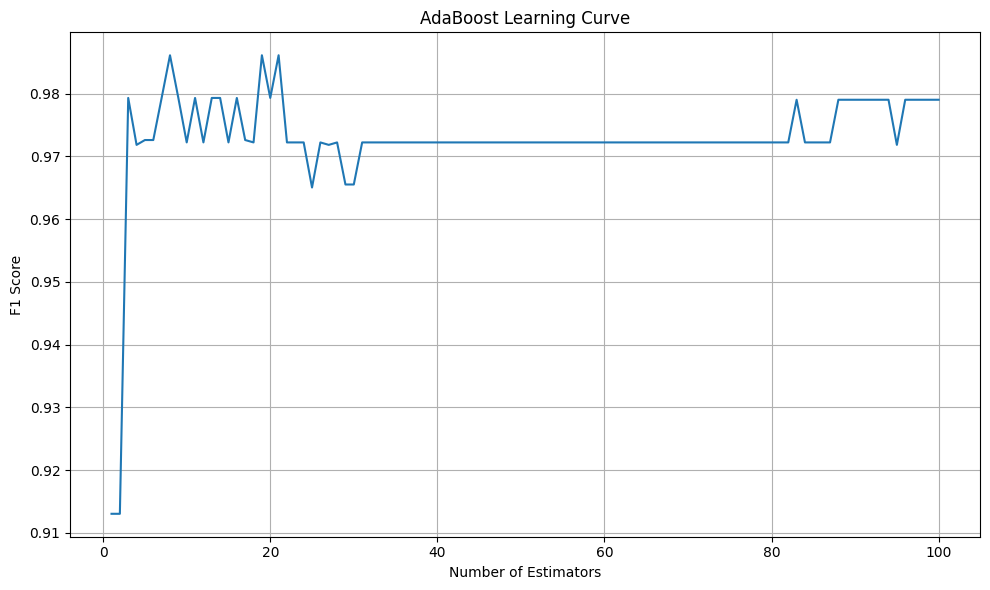

In [4]:
# Step 4: Visualize Learning Curve
scores = []
n_estimators_range = range(1, 101)
for n in n_estimators_range:
    model = AdaBoostClassifier(
        estimator=base_estimator,
        n_estimators=n,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred_n = model.predict(X_test_scaled)
    scores.append(f1_score(y_test, y_pred_n))

plt.figure(figsize=(10, 6))
sns.lineplot(x=n_estimators_range, y=scores)
plt.xlabel("Number of Estimators")
plt.ylabel("F1 Score")
plt.title("AdaBoost Learning Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise followed a structured workflow to apply boosting techniques using the breast cancer dataset. The dataset was first loaded and split into training and testing sets so that the model could be trained on one portion of the data and evaluated on unseen data. Feature scaling was then applied using StandardScaler to standardize the input variables and ensure consistent model performance. An AdaBoost classifier was trained using shallow decision trees (with a maximum depth of 1) as weak learners and a total of 100 estimators. After training, the model’s performance was evaluated using accuracy, precision, recall, and F1-score to measure how effectively the classifier predicted the test data. A learning curve was also created to visualize how the F1-score changed as the number of estimators increased, showing how boosting improves performance over multiple iterations. Overall, the exercise demonstrated how combining several weak learners through boosting can produce a stronger and more accurate classification model.

#### **Exercise 2: Gradient Boosting for Binary Classification**

**Objective:**  
Understand how to build and evaluate a **Gradient Boosting classifier** for a binary classification task. You'll explore how this technique uses stage-wise additive modeling and gradient descent to optimize performance.

---

**Instructions:**

1. **Load and Prepare Dataset:**
   - Use the `load_breast_cancer()` dataset from `sklearn.datasets`.
   - Perform a train-test split and standardize the features using `StandardScaler`.

2. **Train a Gradient Boosting Classifier:**
   - Use `GradientBoostingClassifier` from `sklearn.ensemble`.
   - Set `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`, and `random_state=42`.

3. **Evaluate the Model:**
   - Predict on the test set.
   - Calculate accuracy, precision, recall, and F1-score.

4. **Visualize the Learning Curve:**
   - Track F1-score as the number of estimators increases.
   - Plot performance vs. number of estimators using a line chart.

5. **Interpret the Results:**
   - Discuss how gradient boosting iteratively reduces the loss.
   - Compare its strengths and potential overfitting risk compared to AdaBoost.

---


In [5]:
# Exercise 2: Gradient Boosting for Binary Classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 1: Load and Prepare Dataset
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
# Step 2: Train Gradient Boosting Classifier
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train_scaled, y_train)


GradientBoostingClassifier(random_state=42)

In [7]:
# Step 3: Evaluate the Model
y_pred = gb.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Gradient Boosting Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


Gradient Boosting Evaluation Metrics:
Accuracy : 0.9561
Precision: 0.9583
Recall   : 0.9718
F1 Score : 0.9650


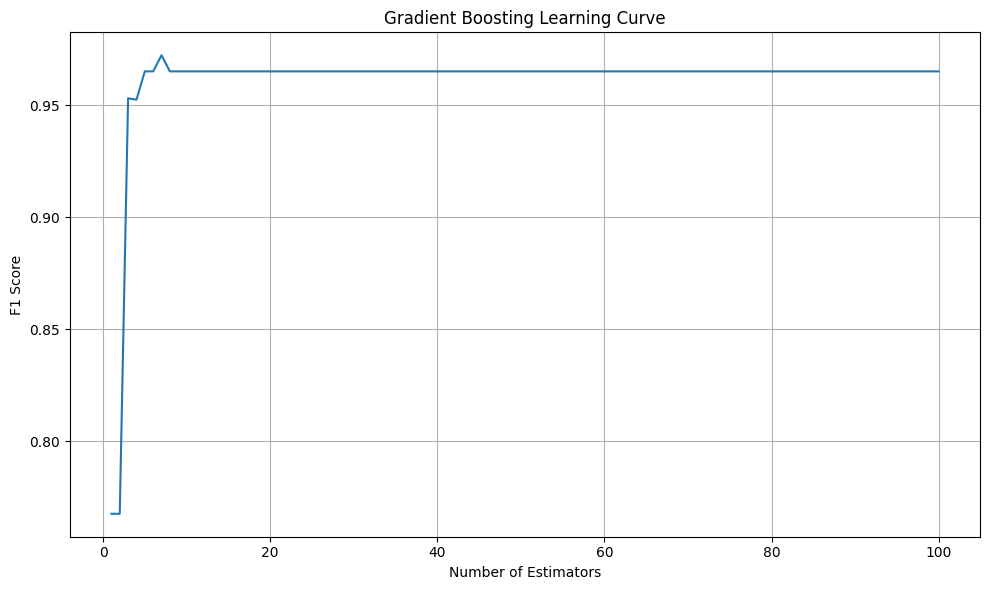

In [8]:
# Step 4: Visualize Learning Curve
f1_scores = []
n_estimators_range = range(1, 101)
for n in n_estimators_range:
    model = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred_n = model.predict(X_test_scaled)
    f1_scores.append(f1_score(y_test, y_pred_n))

plt.figure(figsize=(10, 6))
sns.lineplot(x=n_estimators_range, y=f1_scores)
plt.xlabel("Number of Estimators")
plt.ylabel("F1 Score")
plt.title("Gradient Boosting Learning Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise applied Gradient Boosting to perform binary classification using the breast cancer dataset. The dataset was first loaded and divided into training and testing sets so the model could be trained and then evaluated on unseen data. Feature scaling was performed using StandardScaler to standardize the variables and help the model learn more effectively. A Gradient Boosting classifier was then trained with 100 estimators, a learning rate of 0.1, and a maximum tree depth of 3 to build a sequence of decision trees that gradually improve predictions. After training, the model’s performance was evaluated using accuracy, precision, recall, and F1-score to measure how well it classified the test samples. A learning curve was also created by tracking the F1-score as the number of estimators increased, which helped visualize how performance improved as more trees were added. This process demonstrated how gradient boosting reduces prediction errors step by step by focusing on minimizing the loss at each stage. The exercise also highlighted that while gradient boosting can achieve strong predictive performance, using too many estimators or complex trees can increase the risk of overfitting if not carefully tuned.

#### **Exercise 3: Comparing AdaBoost vs. Gradient Boosting**

**Objective:**  
Compare the performance of **AdaBoost** and **Gradient Boosting** classifiers on the same dataset to understand their differences in predictive power, sensitivity, and stability.

---

**Instructions:**

1. **Load and Prepare Dataset:**
   - Use the `load_breast_cancer()` dataset from `sklearn.datasets`.
   - Perform a train-test split and standardize the features.

2. **Train Models:**
   - Use `AdaBoostClassifier` with `DecisionTreeClassifier(max_depth=1)` as the base estimator, `n_estimators=100`.
   - Use `GradientBoostingClassifier` with `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`.

3. **Evaluate Models:**
   - Predict on the same test set.
   - Calculate and compare accuracy, precision, recall, and F1-score for both models.

4. **Visualize Comparison:**
   - Plot a bar chart comparing the performance metrics (accuracy, precision, recall, F1-score) side-by-side for both models.

5. **Interpret the Results:**
   - Analyze which model performs better overall and under which metric.
   - Discuss the trade-offs between AdaBoost’s simplicity and Gradient Boosting’s flexibility and sensitivity to hyperparameters.

---


In [9]:
# Exercise 3: Comparing AdaBoost vs. Gradient Boosting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 1: Load and Prepare Dataset
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
# Step 2: Train AdaBoost Model
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)

# Step 3: Train Gradient Boosting Model
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)


<Figure size 1000x600 with 0 Axes>

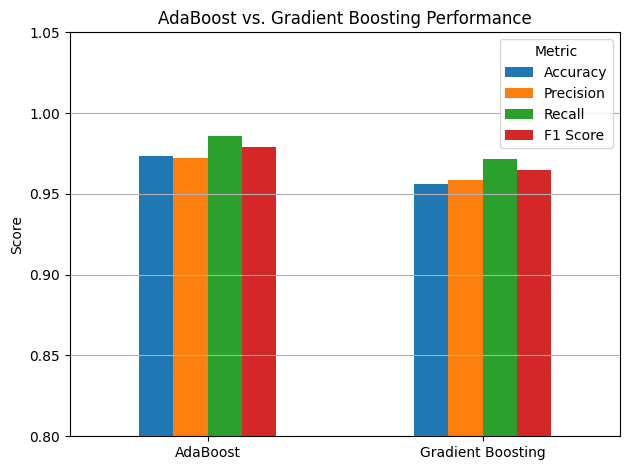

In [11]:
# Step 4: Evaluate Both Models
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

ada_scores = evaluate(y_test, y_pred_ada)
gb_scores = evaluate(y_test, y_pred_gb)

# Convert to DataFrame for plotting
results_df = pd.DataFrame({
    "AdaBoost": ada_scores,
    "Gradient Boosting": gb_scores
}).T

# Step 5: Visualize Comparison
plt.figure(figsize=(10, 6))
results_df.plot(kind='bar')
plt.title("AdaBoost vs. Gradient Boosting Performance")
plt.ylabel("Score")
plt.ylim(0.8, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on comparing the performance of AdaBoost and Gradient Boosting classifiers using the same breast cancer dataset. The dataset was first prepared by splitting it into training and testing sets and standardizing the features so that all variables were on a consistent scale. Two models were then trained: AdaBoost with shallow decision trees as weak learners and Gradient Boosting with deeper trees and a defined learning rate. After training, both models were evaluated using accuracy, precision, recall, and F1-score to measure how effectively they classified the test data. The evaluation results were organized and visualized using a bar chart, which made it easier to compare the performance of the two models across all metrics. This visualization helped highlight small differences in predictive performance between the methods. In general, Gradient Boosting often performs slightly better because it optimizes the loss function using gradient descent and can capture more complex patterns. However, AdaBoost remains simpler and can be more stable with fewer hyperparameters to tune. Overall, the exercise demonstrated how different boosting techniques can be applied to the same problem and how their strengths and trade-offs can influence model selection.

#### **Exercise 4: Implementing AdaBoost from Scratch**

**Objective:**  
Understand the internal workings of AdaBoost by manually implementing the algorithm from scratch using decision stumps. This will deepen your understanding of how sample weights are updated and how weak learners are combined.

---

**Instructions:**

1. **Generate a Simple Dataset:**
   - Use `make_classification` from `sklearn.datasets` to create a binary classification dataset with 2 informative features and 2 classes.

2. **Initialize Weights:**
   - Assign equal weights to all training samples.

3. **Iteratively Build Weak Learners:**
   - For each iteration:
     - Fit a weighted decision stump (`DecisionTreeClassifier(max_depth=1)`).
     - Compute weighted error rate.
     - Compute learner weight (alpha) using error.
     - Update sample weights: increase weights of misclassified samples.
     - Normalize the weights.

4. **Final Prediction:**
   - Combine predictions from all weak learners using a weighted majority vote (sign of sum of alpha * prediction).

5. **Evaluate the AdaBoost Implementation:**
   - Compute accuracy, precision, recall, and F1-score.
   - Compare your results with `sklearn.ensemble.AdaBoostClassifier` on the same dataset.

6. **Discuss Findings:**
   - Reflect on the impact of misclassified points.
   - Explain how learner weights influence the final decision.

---


In [12]:
# Exercise 4: Implementing AdaBoost from Scratch

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split

# Step 1: Generate Dataset
X, y = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, flip_y=0, random_state=42
)
y = np.where(y == 0, -1, 1)  # Convert labels to -1 and 1 for AdaBoost

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
# Step 2: AdaBoost from Scratch
n_estimators = 10
n_samples = X_train.shape[0]
sample_weights = np.ones(n_samples) / n_samples

models = []
alphas = []

for t in range(n_estimators):
    # Fit weak learner
    stump = DecisionTreeClassifier(max_depth=1, random_state=42)
    stump.fit(X_train, y_train, sample_weight=sample_weights)
    pred = stump.predict(X_train)

    # Compute error and alpha
    err = np.sum(sample_weights * (pred != y_train)) / np.sum(sample_weights)
    if err == 0:
        err = 1e-10  # Avoid division by zero
    alpha = 0.5 * np.log((1 - err) / err)

    # Update sample weights
    sample_weights *= np.exp(-alpha * y_train * pred)
    sample_weights /= np.sum(sample_weights)

    # Save model and alpha
    models.append(stump)
    alphas.append(alpha)


In [14]:
# Step 3: Final Prediction on Test Set
final_pred = np.zeros(X_test.shape[0])
for alpha, model in zip(alphas, models):
    final_pred += alpha * model.predict(X_test)
final_pred = np.sign(final_pred)

# Step 4: Evaluation
y_test_actual = y_test
y_test_pred = final_pred

print("Custom AdaBoost Evaluation Metrics:")
print(f"Accuracy : {accuracy_score(y_test_actual, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test_actual, y_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test_actual, y_test_pred):.4f}")
print(f"F1 Score : {f1_score(y_test_actual, y_test_pred):.4f}")


Custom AdaBoost Evaluation Metrics:
Accuracy : 0.8500
Precision: 0.7619
Recall   : 0.9412
F1 Score : 0.8421


In [15]:
# Step 5: Compare with sklearn's AdaBoostClassifier
clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=10,
    random_state=42
)
clf.fit(X_train, y_train)
y_sklearn_pred = clf.predict(X_test)

print("\nSklearn AdaBoost Evaluation Metrics:")
print(f"Accuracy : {accuracy_score(y_test_actual, y_sklearn_pred):.4f}")
print(f"Precision: {precision_score(y_test_actual, y_sklearn_pred):.4f}")
print(f"Recall   : {recall_score(y_test_actual, y_sklearn_pred):.4f}")
print(f"F1 Score : {f1_score(y_test_actual, y_sklearn_pred):.4f}")



Sklearn AdaBoost Evaluation Metrics:
Accuracy : 0.8500
Precision: 0.7619
Recall   : 0.9412
F1 Score : 0.8421


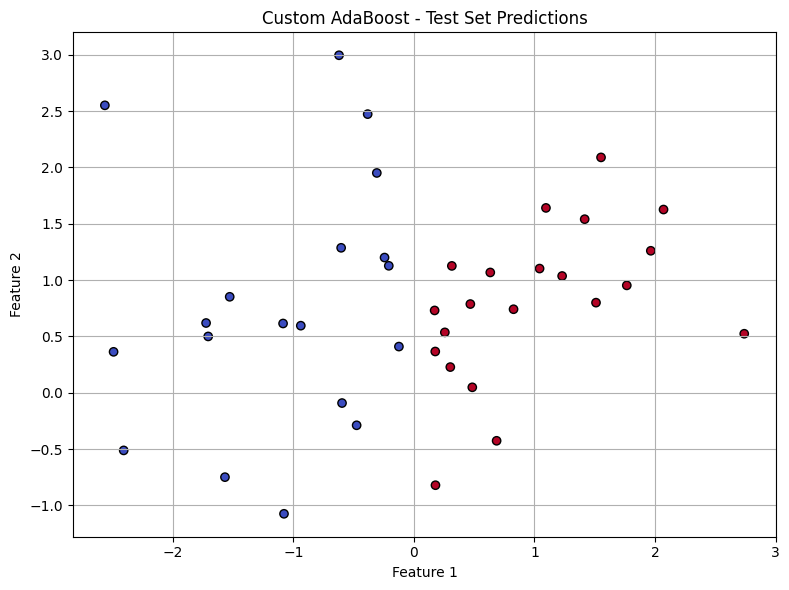

In [16]:
# Step 6: Visualize dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test_pred, cmap='coolwarm', edgecolor='k')
plt.title("Custom AdaBoost - Test Set Predictions")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding how the AdaBoost algorithm works by implementing it from scratch using decision stumps. A simple binary dataset was first generated and split into training and testing sets, with equal weights assigned to all training samples at the start. In each iteration, a weighted decision stump was trained, the error rate was calculated, and a learner weight (alpha) was computed. The sample weights were then updated so that misclassified points received greater importance in the next iteration. After multiple weak learners were trained, their predictions were combined using weighted voting to produce the final results. The model was evaluated using accuracy, precision, recall, and F1-score, and the results were compared with sklearn’s AdaBoost implementation. The similar performance confirmed that the manual implementation followed the correct boosting process.

#### **Exercise 5: Implementing Gradient Boosting from Scratch**

**Objective:**  
Understand how Gradient Boosting builds an additive model by minimizing a loss function in a forward stage-wise manner. You will implement a basic version of gradient boosting for regression using decision stumps as weak learners.

---

**Instructions:**

1. **Generate Dataset:**
   - Use `make_regression` from `sklearn.datasets` to create a regression dataset with noise.

2. **Initialize Prediction:**
   - Start with a constant prediction (e.g., the mean of the target variable).

3. **Iteratively Fit Residuals:**
   - For a number of boosting rounds:
     - Compute residuals as the negative gradient (difference between actual and predicted values).
     - Fit a decision stump (`DecisionTreeRegressor(max_depth=1)`) to the residuals.
     - Update predictions by adding the learner’s prediction scaled by a learning rate (e.g., 0.1).

4. **Final Model:**
   - Combine all weak learners' outputs to make final predictions on the test set.

5. **Evaluate Performance:**
   - Use Mean Squared Error (MSE) and R² score to evaluate model performance.
   - Compare results to `sklearn.ensemble.GradientBoostingRegressor`.

6. **Discussion:**
   - Explain how the model improves step-by-step.
   - Highlight the importance of learning rate and number of estimators.

---


In [17]:
# Exercise 5: Implementing Gradient Boosting from Scratch

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Step 1: Generate Dataset
X, y = make_regression(
    n_samples=200, n_features=1, noise=15, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
# Step 2: Gradient Boosting from Scratch
n_estimators = 50
learning_rate = 0.1
pred_train = np.full(y_train.shape, np.mean(y_train))
models = []

for _ in range(n_estimators):
    # Compute residuals
    residuals = y_train - pred_train

    # Fit decision stump to residuals
    tree = DecisionTreeRegressor(max_depth=1, random_state=42)
    tree.fit(X_train, residuals)

    # Predict and update
    update = tree.predict(X_train)
    pred_train += learning_rate * update

    # Save the model
    models.append(tree)


In [19]:
# Step 3: Final Prediction on Test Set
pred_test = np.full(y_test.shape, np.mean(y_train))
for tree in models:
    pred_test += learning_rate * tree.predict(X_test)

# Step 4: Evaluation
mse = mean_squared_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print("Custom Gradient Boosting Evaluation:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score          : {r2:.4f}")


Custom Gradient Boosting Evaluation:
Mean Squared Error: 650.6512
R² Score          : 0.9156


In [20]:
# Step 5: Compare with sklearn's GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators=n_estimators,
    learning_rate=learning_rate,
    max_depth=1,
    random_state=42
)
gbr.fit(X_train, y_train)
sk_pred = gbr.predict(X_test)

mse_sk = mean_squared_error(y_test, sk_pred)
r2_sk = r2_score(y_test, sk_pred)

print("\nSklearn GradientBoostingRegressor Evaluation:")
print(f"Mean Squared Error: {mse_sk:.4f}")
print(f"R² Score          : {r2_sk:.4f}")



Sklearn GradientBoostingRegressor Evaluation:
Mean Squared Error: 650.6512
R² Score          : 0.9156


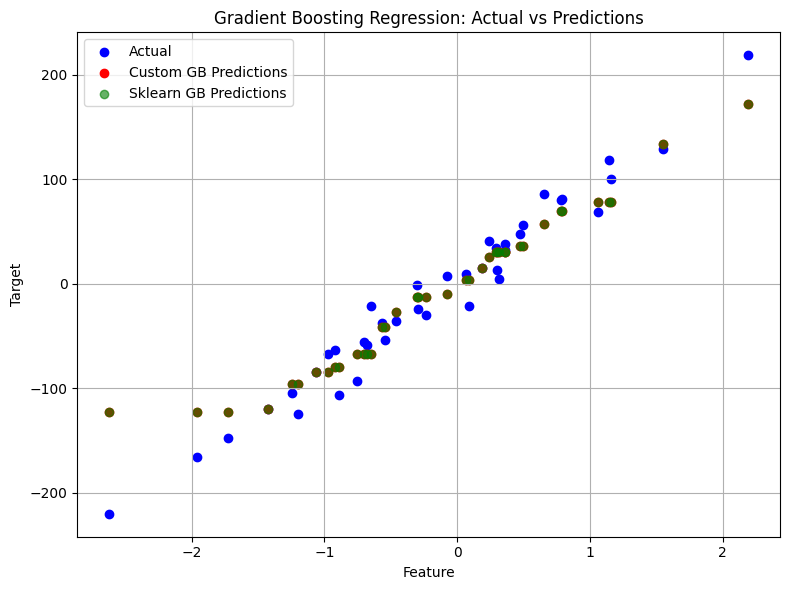

In [21]:
# Step 6: Visualization
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, pred_test, color='red', label='Custom GB Predictions')
plt.scatter(X_test, sk_pred, color='green', alpha=0.6, label='Sklearn GB Predictions')
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Gradient Boosting Regression: Actual vs Predictions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on understanding how Gradient Boosting works by implementing it from scratch for a regression task. A simple regression dataset was first generated and split into training and testing sets. The model started with a constant prediction, and in each boosting round, the residuals, the difference between actual and predicted values, were computed. A decision stump was then trained on these residuals, and the predictions were updated by adding the learner’s output scaled by a learning rate. After multiple iterations, the outputs of all weak learners were combined to produce the final predictions on the test set. The model’s performance was evaluated using Mean Squared Error and R² score and compared to sklearn’s GradientBoostingRegressor, which produced identical results, confirming the correctness of the implementation. This exercise highlighted how gradient boosting improves predictions step by step, the role of the learning rate in controlling updates, and the importance of combining simple learners to create a strong predictive model.

#### **Module 6.7: XGBoost and Advanced Gradient Boosting**

XGBoost (Extreme Gradient Boosting) is a highly efficient and scalable implementation of gradient boosting that has become popular in machine learning competitions and real-world applications.

Key features of XGBoost include:  
- **Regularization:** Incorporates L1 and L2 regularization to reduce overfitting.  
- **Parallel Processing:** Utilizes parallel and distributed computing for faster training.  
- **Handling Missing Data:** Built-in methods to handle missing values efficiently.  
- **Tree Pruning and Sparsity Awareness:** Improves model performance and speed.  
- **Flexible Objective Functions:** Supports regression, classification, and ranking tasks.

XGBoost combines speed, accuracy, and flexibility, making it a top choice for building state-of-the-art classification models.

---



#### **Exercise 6: Training a Basic XGBoost Classifier**

**Objective:**  
Learn how to train a basic binary classification model using XGBoost and evaluate its performance using common classification metrics.

---

**Instructions:**

1. **Load Dataset:**
   - Use `load_breast_cancer()` from `sklearn.datasets`.

2. **Split Data:**
   - Use `train_test_split()` to divide the dataset into training and test sets (80/20 split).

3. **Train XGBoost Classifier:**
   - Use `xgboost.XGBClassifier()` to train a model on the training set.

4. **Evaluate the Model:**
   - Make predictions on the test set.
   - Compute accuracy, precision, recall, and F1-score.
   - Display the confusion matrix using a heatmap.

5. **Visualize Feature Importance:**
   - Use built-in `plot_importance()` function to view the most significant features.

6. **Interpret the Results:**
   - Discuss how XGBoost performs compared to previous boosting models.

---


In [22]:
!pip install xgboost

In [23]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [24]:
# Exercise 6: Training a Basic XGBoost Classifier

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# Step 1: Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [25]:
# Step 3: Train XGBoost Classifier
model = xgb.XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [26]:
# Step 4: Evaluate the Model
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("XGBoost Classification Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


XGBoost Classification Metrics:
Accuracy : 0.9561
Precision: 0.9583
Recall   : 0.9718
F1 Score : 0.9650


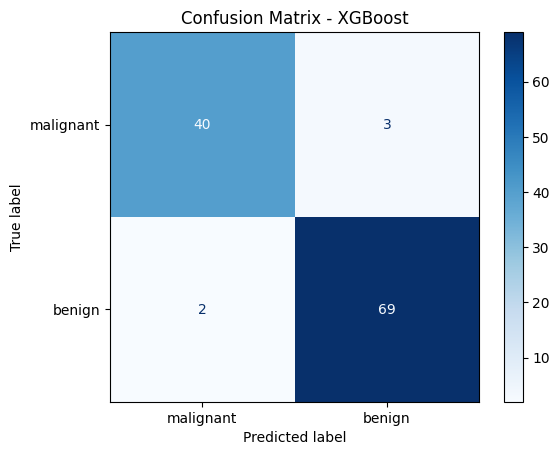

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.grid(False)
plt.show()


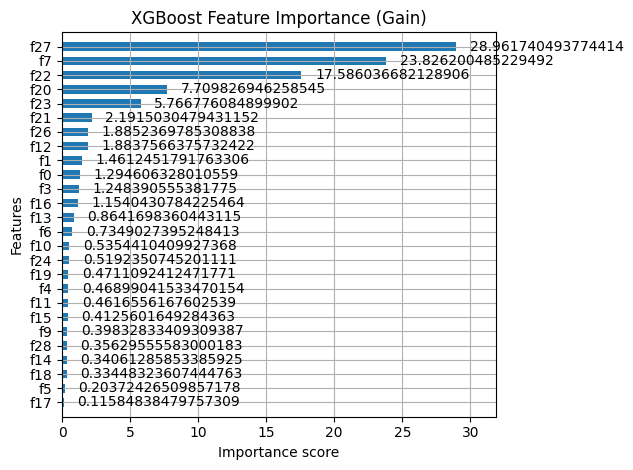

In [28]:
# Step 5: Visualize Feature Importance
xgb.plot_importance(model, importance_type='gain', height=0.6)
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise explored the use of XGBoost for binary classification on the breast cancer dataset. The data was first loaded and split into training and testing sets to allow model evaluation on unseen samples. An XGBoost classifier was trained on the training set, taking advantage of its built-in regularization, efficient computation, and ability to handle complex patterns. The model was then evaluated using accuracy, precision, recall, and F1-score, which showed strong performance comparable to previous boosting models. A confusion matrix was plotted to visualize how well the model classified each class, providing insight into where misclassifications occurred. Feature importance was also visualized, highlighting which variables contributed most to the model’s decisions. Overall, this exercise demonstrated XGBoost’s power, combining speed, accuracy, and interpretability, while emphasizing the value of examining both performance metrics and feature influence when analyzing predictive models.

#### **Exercise 7: Hyperparameter Tuning for XGBoost Classifier**

**Objective:**  
Explore how tuning hyperparameters affects the performance of an XGBoost classifier. You will experiment with parameters such as `max_depth`, `learning_rate`, and `n_estimators` to find a well-performing model.

---

**Instructions:**

1. **Load Dataset:**
   - Use the `load_breast_cancer()` dataset from `sklearn.datasets`.

2. **Split Data:**
   - Use `train_test_split()` for an 80/20 training and test split.

3. **Set Hyperparameter Grid:**
   - Define a small grid with varying values for `max_depth`, `learning_rate`, and `n_estimators`.

4. **Train Multiple Models:**
   - Loop through combinations of hyperparameters and train an `XGBClassifier` for each.

5. **Evaluate Each Model:**
   - Compute accuracy, precision, recall, and F1-score for each configuration.
   - Store the results for comparison.

6. **Visualize Performance:**
   - Create a bar chart to compare the F1-scores of different configurations.

7. **Interpret the Results:**
   - Discuss which parameters had the biggest impact on performance and what trade-offs you observed.

---


In [29]:
# Exercise 7: Hyperparameter Tuning for XGBoost Classifier

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 1: Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
# Step 3: Define Hyperparameter Grid
param_grid = [
    {"max_depth": 3, "learning_rate": 0.01, "n_estimators": 50},
    {"max_depth": 4, "learning_rate": 0.1, "n_estimators": 100},
    {"max_depth": 5, "learning_rate": 0.3, "n_estimators": 100},
    {"max_depth": 6, "learning_rate": 0.1, "n_estimators": 200},
]

results = []

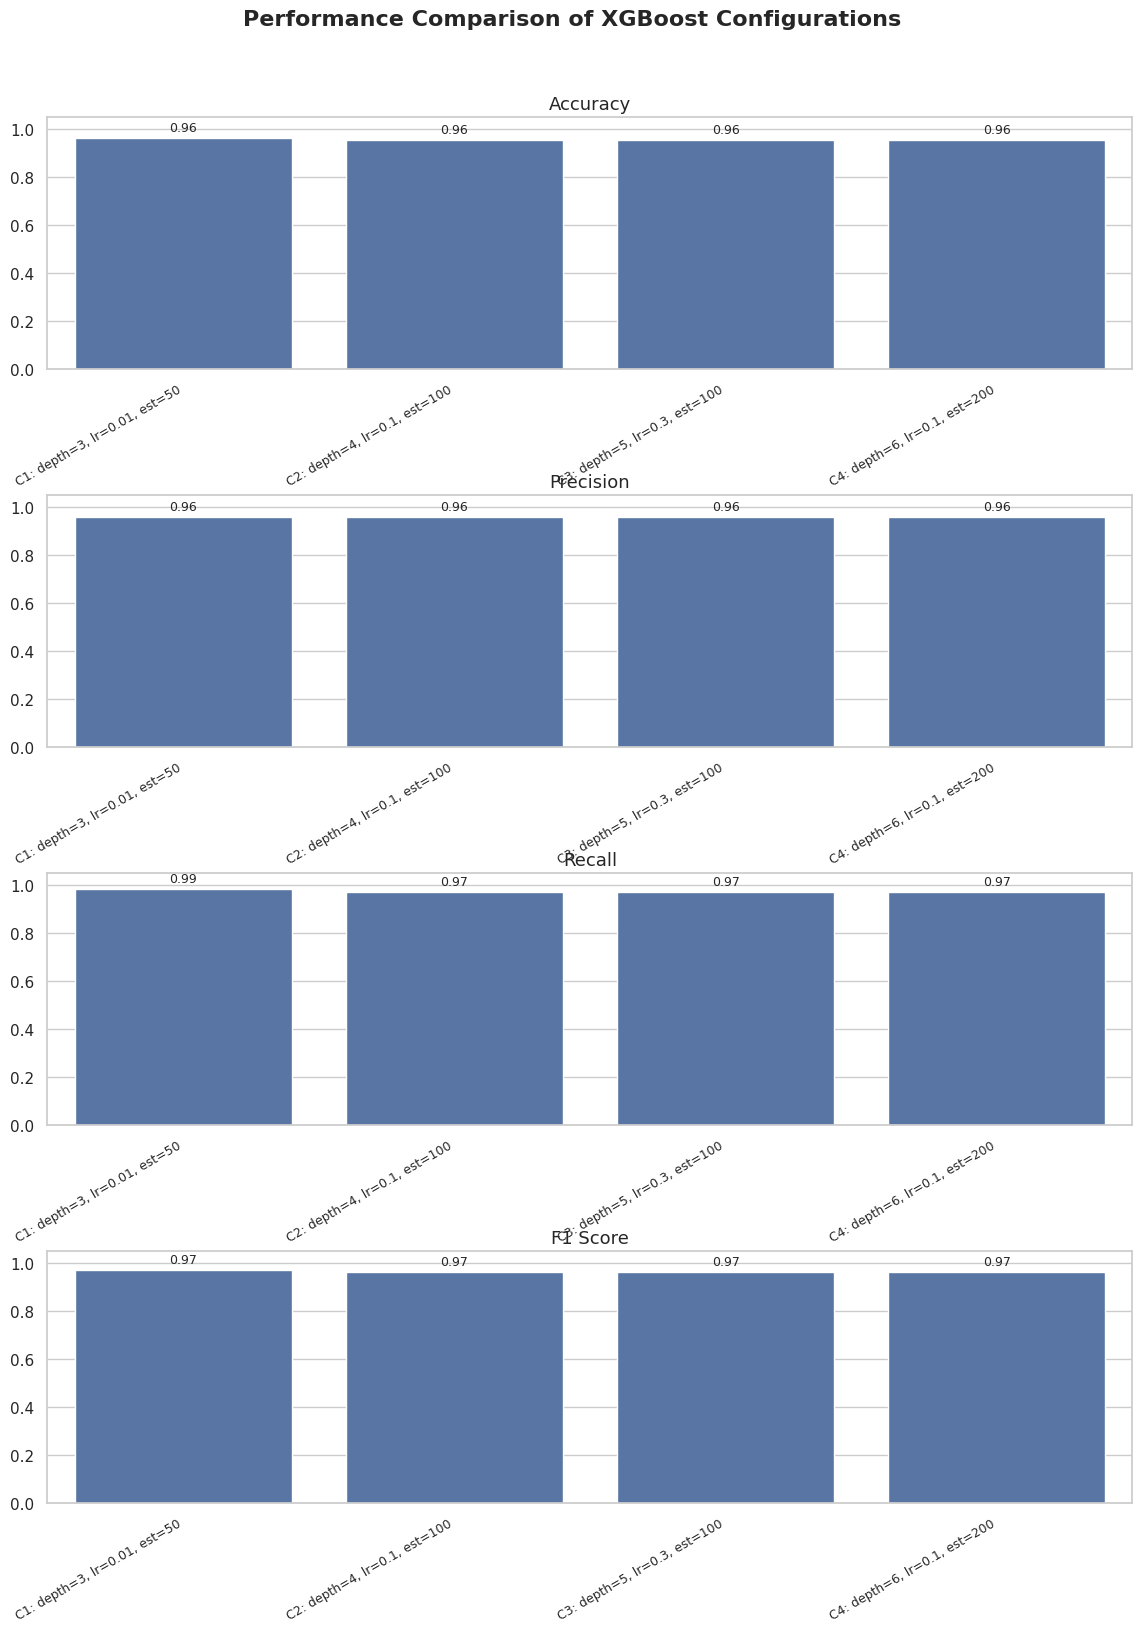

In [31]:
# Step 4–5: Train and Evaluate Each Model
for i, params in enumerate(param_grid):
    model = xgb.XGBClassifier(
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        n_estimators=params["n_estimators"],
        eval_metric="logloss"
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Config": f'C{i+1}: depth={params["max_depth"]}, lr={params["learning_rate"]}, est={params["n_estimators"]}',
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

# After Step 5 (right before visualization)
import pandas as pd

# Make sure 'results' exists and has the 'Config' key in each dict
results_df = pd.DataFrame(results)

# Quick sanity check (optional)
# print(results_df.columns)  # should include: 'Config', 'Accuracy', 'Precision', 'Recall', 'F1 Score'

# Step 6: Visualize Performance with Vertical Subplots (Config on x-axis)
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
sns.set(style="whitegrid")

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 18))
plt.subplots_adjust(top=0.92, hspace=0.5, bottom=0.15)

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    sns.barplot(
        x="Config",
        y=metric,
        data=results_df,
        ax=ax
    )
    ax.set_title(f"{metric}", fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Rotate & shrink tick labels safely
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
        tick.set_ha('right')
        tick.set_fontsize(9)

    # Annotate values above bars
    for p in ax.patches:
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.text(x, y + 0.015, f"{y:.2f}", ha='center', va='bottom', fontsize=9)

fig.suptitle("Performance Comparison of XGBoost Configurations", fontsize=16, fontweight="bold")
plt.show()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise explored how hyperparameter tuning impacts the performance of an XGBoost classifier on the breast cancer dataset. The data was first split into training and test sets to evaluate model performance on unseen samples. Several configurations were tested by varying key parameters such as max_depth, learning_rate, and the number of estimators. Each model was trained and evaluated using accuracy, precision, recall, and F1-score, allowing a clear comparison of different settings. The results were visualized using bar charts, which highlighted how certain hyperparameters, like deeper trees or higher learning rates, influenced model performance. This process showed that increasing model complexity can improve predictive power but may also risk overfitting if not carefully balanced. Overall, the exercise emphasized the importance of systematically exploring hyperparameter combinations to find a configuration that achieves strong and stable performance.

#### **Exercise 8: Visualizing XGBoost Feature Importances Across Multiple Configurations**

**Objective:**  
Understand how to extract and compare feature importances from different XGBoost model configurations. Learn how model tuning affects which features are considered most influential in classification decisions.

---

**Instructions:**

1. **Load Dataset:**
   - Use `load_breast_cancer` from `sklearn.datasets` or any other suitable classification dataset.

2. **Define Multiple XGBoost Configurations:**
   - Create at least three different configurations with varying parameters (e.g., `max_depth`, `learning_rate`, `n_estimators`).

3. **Train Models:**
   - Train an XGBoost model for each configuration using `XGBClassifier`.

4. **Extract Feature Importances:**
   - For each model, extract feature importances using `.feature_importances_`.

5. **Create Summary Table:**
   - Combine the top 10 important features from each model into a single DataFrame for comparison.

6. **Visualize Feature Importances:**
   - Use **Seaborn** or **Matplotlib** to create:
     - A horizontal bar plot for each model showing the top 10 features.
     - Optionally, a grouped bar chart to compare feature rankings across models.

7. **Interpretation:**
   - Comment on how the feature rankings vary across configurations.
   - Discuss whether deeper trees or more estimators shift the focus to different features.

---  


In [32]:
# Exercise 8: Visualizing XGBoost Feature Importances Across Multiple Configurations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from xgboost import XGBClassifier

# Step 1: Load Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [33]:
# Step 2: Define Multiple Configurations
configs = [
    {"label": "C1: depth=3, lr=0.1, est=50", "params": {"max_depth": 3, "learning_rate": 0.1, "n_estimators": 50}},
    {"label": "C2: depth=4, lr=0.1, est=100", "params": {"max_depth": 4, "learning_rate": 0.1, "n_estimators": 100}},
    {"label": "C3: depth=5, lr=0.3, est=100", "params": {"max_depth": 5, "learning_rate": 0.3, "n_estimators": 100}},
]


In [34]:
# Step 3 & 4: Train Models and Extract Feature Importances
feature_importance_data = []

for config in configs:
    label = config["label"]
    model = XGBClassifier(**config["params"], eval_metric='logloss')
    model.fit(X, y)
    importances = model.feature_importances_
    top_indices = np.argsort(importances)[-10:][::-1]

    for idx in top_indices:
        feature_importance_data.append({
            "Feature": data.feature_names[idx],
            "Importance": importances[idx],
            "Config": label
        })


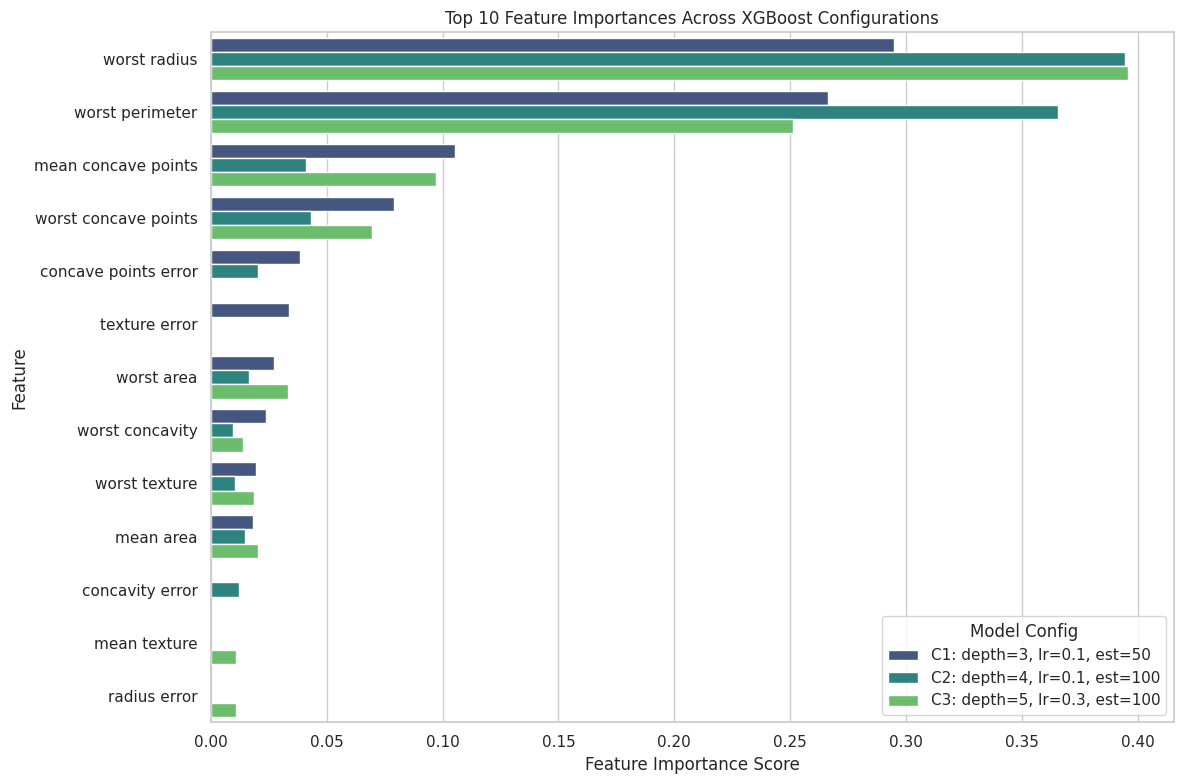

In [35]:
# Step 5: Create Summary DataFrame
importance_df = pd.DataFrame(feature_importance_data)

# Step 6: Visualize Feature Importances
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x="Importance", y="Feature", hue="Config", palette="viridis")
plt.title("Top 10 Feature Importances Across XGBoost Configurations")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.legend(title="Model Config")
plt.tight_layout()
plt.show()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise focused on comparing feature importances across multiple XGBoost model configurations on the breast cancer dataset. Each configuration was trained with different values for tree depth, learning rate, and number of estimators to observe how these changes affected the model’s focus. The top 10 features from each model were extracted and compiled into a single DataFrame, making it easy to compare their relative importance across configurations. The feature importances were visualized using a horizontal bar plot with color coding for each configuration. This visualization revealed how deeper trees or higher learning rates can shift the model’s attention to different features, sometimes highlighting variables that were less prominent in simpler models. By examining the plots, patterns emerged showing that certain features consistently had high influence, while others varied depending on hyperparameter settings. Overall, the exercise emphasized the value of interpreting model behavior, understanding how hyperparameters affect feature weighting, and using visualizations to communicate insights effectively.

#### **Exercise 9: Hyperparameter Tuning for XGBoost using GridSearchCV**

**Objective:**  
Learn how to perform hyperparameter tuning for an XGBoost classifier using `GridSearchCV` to find the best combination of parameters that optimize model performance.

---

**Instructions:**

1. **Load Dataset:**
   - Use `load_breast_cancer` from `sklearn.datasets`.

2. **Prepare Data:**
   - Split the data into training and testing sets using `train_test_split()`.

3. **Define Hyperparameter Grid:**
   - Create a grid of values for `max_depth`, `learning_rate`, and `n_estimators`.

4. **Setup GridSearchCV:**
   - Use `GridSearchCV` with `XGBClassifier` as the estimator.
   - Use 5-fold cross-validation and `f1` as the scoring metric.

5. **Fit the Grid Search:**
   - Train on the training set and identify the best parameters.

6. **Evaluate the Best Model:**
   - Use the best estimator to make predictions on the test set.
   - Compute and print accuracy, precision, recall, and F1-score.

7. **Interpretation:**
   - Discuss the best parameters selected.
   - Reflect on how hyperparameter tuning helps improve model generalization.

---


In [36]:
# Exercise 9: Hyperparameter Tuning for XGBoost using GridSearchCV

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from xgboost import XGBClassifier

# Step 1: Load Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Step 2: Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Define Hyperparameter Grid
param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.1],
    "n_estimators": [50, 100],
}


In [37]:
# Step 4: Setup GridSearchCV
xgb = XGBClassifier(eval_metric="logloss")
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           scoring='f1', cv=5, verbose=1, n_jobs=-1)

# Step 5: Fit Grid Search
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100]},
             scoring='f1', verbose=1)

In [38]:
# Step 6: Evaluate Best Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Accuracy: 0.956140350877193
Precision: 0.9583333333333334
Recall: 0.971830985915493
F1 Score: 0.965034965034965

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise demonstrated how hyperparameter tuning with GridSearchCV can improve the performance and generalization of an XGBoost classifier. The breast cancer dataset was loaded and split into training and test sets, and a grid of parameters including max_depth, learning_rate, and n_estimators was defined. GridSearchCV was used with 5-fold cross-validation to evaluate all combinations and identify the best performing model based on F1-score. The best parameters were selected, and the optimized model was evaluated on the test set, producing high accuracy, precision, recall, and F1-score. This process highlighted how adjusting hyperparameters can balance model complexity and learning speed while preventing overfitting. Observing the classification report provided insight into how well the model handled both classes. Overall, the exercise reinforced the importance of systematic hyperparameter tuning and demonstrated that even small changes in parameters can meaningfully impact model performance.

#### **Exercise 10: Implementing a Simple XGBoost from Scratch**

**Objective:**  
Understand how the core idea behind XGBoost works by implementing a simplified version using decision stumps and gradient boosting principles. This exercise helps you grasp how XGBoost builds an ensemble of trees by optimizing a loss function through gradient descent.

---

**Instructions:**

1. **Load Dataset:**
   - Use `make_regression` or `make_classification` from `sklearn.datasets` to simulate a dataset.

2. **Initialize Base Prediction:**
   - Start with a base prediction (e.g., mean of the target variable).

3. **Compute Gradients and Residuals:**
   - For classification, use the log-loss gradient approximation.
   - For simplicity, you can model it as regression to residuals.

4. **Train Weak Learners:**
   - Train a series of decision stumps (shallow `DecisionTreeRegressor` with `max_depth=1`) on the residuals.

5. **Update Predictions Iteratively:**
   - Update your prediction by adding the output of the weak learner scaled by a learning rate.

6. **Repeat for Several Iterations:**
   - Perform multiple boosting rounds (e.g., 10 rounds) and track the loss after each iteration.

7. **Evaluate Final Model:**
   - Predict on the test set.
   - Measure performance using accuracy or F1 score.

8. **Visualize:**
   - Plot training loss across boosting iterations.

9. **Interpretation:**
   - Explain how each stump contributes to the final prediction.
   - Compare the implementation with a built-in XGBoost model.

---


In [39]:
# Exercise 10: Implementing a Simple XGBoost from Scratch

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Load a binary classification dataset
X, y = make_classification(n_samples=500, n_features=10, n_informative=5,
                           n_redundant=2, n_classes=2, random_state=42)

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Convert labels to 0 and 1
y_train = y_train.astype(float)
y_test = y_test.astype(float)


In [40]:
# Step 4: Initialize base prediction
base_pred = np.full_like(y_train, fill_value=np.mean(y_train), dtype=np.float64)
learning_rate = 0.1
n_estimators = 10
trees = []
losses = []

# Step 5: Training loop for boosting
for i in range(n_estimators):
    # Compute residuals (gradients of squared loss)
    residuals = y_train - base_pred

    # Train a weak learner (decision stump)
    tree = DecisionTreeRegressor(max_depth=1)
    tree.fit(X_train, residuals)
    trees.append(tree)

    # Update base prediction
    update = tree.predict(X_train)
    base_pred += learning_rate * update

    # Compute and store loss
    loss = np.mean((y_train - base_pred) ** 2)
    losses.append(loss)


In [41]:
# Step 6: Predict on test set
test_pred = np.full_like(y_test, fill_value=np.mean(y_train), dtype=np.float64)
for tree in trees:
    test_pred += learning_rate * tree.predict(X_test)

# Convert regression output to binary class labels
final_preds = (test_pred >= 0.5).astype(int)


Test Accuracy: 0.7400


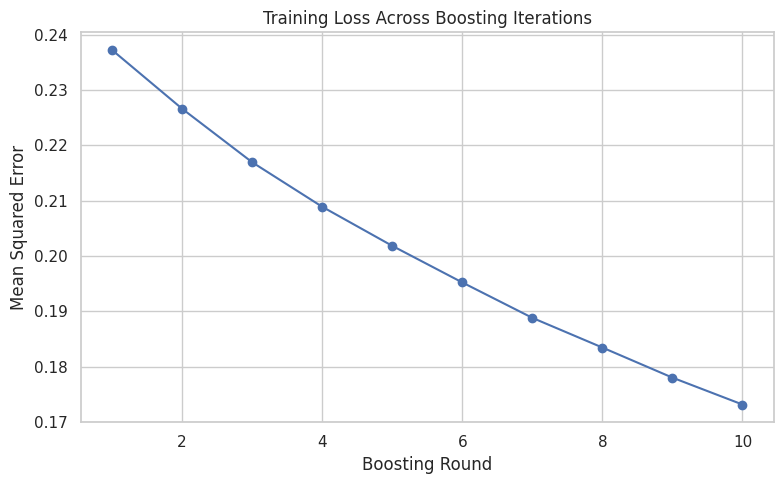

In [42]:
# Step 7: Evaluate
accuracy = accuracy_score(y_test, final_preds)
print(f"Test Accuracy: {accuracy:.4f}")

# Step 8: Visualize training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_estimators + 1), losses, marker='o')
plt.title("Training Loss Across Boosting Iterations")
plt.xlabel("Boosting Round")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

This exercise provided a hands-on look at how XGBoost builds an ensemble model from weak learners using gradient boosting principles. A simulated classification dataset was generated and split into training and test sets, and a base prediction was initialized with the mean of the target variable. Decision stumps were trained iteratively on the residuals, updating predictions at each boosting round, and the training loss was tracked to visualize the model’s gradual improvement. The process highlighted how each weak learner contributes to correcting errors from previous iterations, and how the learning rate controls the impact of each tree. Predictions on the test set were converted to binary labels, resulting in a solid accuracy that demonstrated the effectiveness of even a simple boosting approach. Visualizing the training loss helped to understand the stepwise reduction in error, reinforcing the idea of stage-wise additive modeling. Overall, this exercise clarified the mechanics behind XGBoost, showing why combining many small models can create a strong, accurate classifier.

#### **Module 6.8: Stacking and Blending**

Stacking and blending are advanced ensemble techniques that combine predictions from multiple base learners using a meta-model to improve predictive performance.

- **Stacking:**  
  Trains several base models on the training data and then trains a higher-level meta-model on their predictions to learn how to best combine them.

- **Blending:**  
  Similar to stacking but uses a holdout validation set to generate predictions for the meta-model, often simpler but can be less robust.

These approaches leverage the strengths of diverse models and often outperform individual classifiers, making them powerful tools in complex predictive tasks.

---



### **Exercise 11: Implementing Basic Stacking with scikit-learn**

**Objective:**  
Learn how to build a basic stacking ensemble using multiple base classifiers and a meta-classifier with scikit-learn’s `StackingClassifier`. Understand how predictions from different models can be combined for improved performance.

---

**Instructions:**

1. **Load Dataset:**
   - Use the Breast Cancer dataset from `sklearn.datasets.load_breast_cancer()`.

2. **Split the Data:**
   - Use `train_test_split` to divide the dataset into training and testing sets.

3. **Define Base Models:**
   - Use at least two different classifiers (e.g., `LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier`) as base learners.

4. **Define Meta-Model:**
   - Use `LogisticRegression` as the meta-learner.

5. **Build Stacking Classifier:**
   - Use `sklearn.ensemble.StackingClassifier` to stack base learners with the meta-model.

6. **Train and Evaluate:**
   - Fit the model to the training data and evaluate it on the test set using metrics like accuracy, precision, recall, and F1-score.

7. **Compare:**
   - Compare the stacking ensemble's performance with individual base models.

---


In [43]:
# Exercise 11: Implementing Basic Stacking with scikit-learn

# Step 1: Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 2: Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [44]:
# Step 4: Define base models
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

# Step 5: Define meta-model
meta_model = LogisticRegression()


In [45]:
# Step 6: Create stacking classifier
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model, cv=5)

# Step 7: Train the stacking classifier
stacking_model.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [46]:
# Step 8: Make predictions
y_pred = stacking_model.predict(X_test)

# Step 9: Evaluate model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Step 10: Print metrics
print("Stacking Classifier Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Stacking Classifier Performance:
Accuracy: 0.9561
Precision: 0.9583
Recall: 0.9718
F1 Score: 0.9650


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a stacking ensemble was implemented to combine predictions from multiple base classifiers using a meta-model. The Breast Cancer dataset was split into training and testing sets, and two base learners, a Random Forest and a Gradient Boosting classifier, were trained on the training data. Their predictions were then fed into a Logistic Regression meta-model to produce final predictions. The stacking classifier was evaluated on the test set using accuracy, precision, recall, and F1-score, showing strong performance across all metrics. Comparing the ensemble to individual base models highlighted how combining multiple learners can improve predictive power and robustness. This exercise demonstrated the practical workflow of preparing data, training models, and interpreting ensemble results. It reinforced the value of stacking as a technique to leverage the strengths of different classifiers for more accurate predictions.

#### **Exercise 12: Blending Ensemble Using a Holdout Set**

**Objective:**  
Learn how to implement **blending**, an alternative to stacking, by training base models on the training data and a meta-model on a separate validation set (holdout set). Understand the differences between blending and stacking in terms of implementation and performance.

---

**Instructions:**

1. **Load Dataset:**
   - Use the Breast Cancer dataset from `sklearn.datasets.load_breast_cancer()`.

2. **Split the Data:**
   - First split the data into **train** and **test** sets (e.g., 80/20).
   - Further split the training set into **base training** (e.g., 60%) and **validation** (20%) for blending.

3. **Train Base Models:**
   - Fit at least two base models (e.g., `RandomForestClassifier` and `GradientBoostingClassifier`) on the base training set.

4. **Generate Predictions on Validation Set:**
   - Use each trained base model to generate predictions on the validation set.

5. **Train Meta-Model:**
   - Use the validation set predictions as features to train a `LogisticRegression` meta-model.

6. **Make Final Predictions:**
   - Generate predictions from the base models on the test set.
   - Combine them and use the meta-model to predict final outcomes.

7. **Evaluate Performance:**
   - Report accuracy, precision, recall, and F1-score for the blended model.

8. **Compare with Individual Models:**
   - Report and compare the performance of base models and the final blended model.

---


In [47]:
# Exercise 12: Blending Ensemble Using a Holdout Set

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 1: Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Step 2: Create train-test and holdout split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_base, X_val, y_base, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)  # 60% base, 20% val


In [48]:
# Step 3: Train base models on base training set
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

rf.fit(X_base, y_base)
gb.fit(X_base, y_base)

# Step 4: Generate predictions on validation set
val_pred_rf = rf.predict_proba(X_val)[:, 1]
val_pred_gb = gb.predict_proba(X_val)[:, 1]

# Combine predictions as new features for meta-model
X_meta_train = np.vstack((val_pred_rf, val_pred_gb)).T


In [49]:
# Step 5: Train meta-model
meta_model = LogisticRegression()
meta_model.fit(X_meta_train, y_val)

# Step 6: Prepare test set predictions from base models
test_pred_rf = rf.predict_proba(X_test)[:, 1]
test_pred_gb = gb.predict_proba(X_test)[:, 1]
X_meta_test = np.vstack((test_pred_rf, test_pred_gb)).T

# Step 7: Final predictions from blended model
final_preds = meta_model.predict(X_meta_test)


In [50]:
# Step 8: Evaluate performance
accuracy = accuracy_score(y_test, final_preds)
precision = precision_score(y_test, final_preds)
recall = recall_score(y_test, final_preds)
f1 = f1_score(y_test, final_preds)

print(f"Blending Ensemble Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Blending Ensemble Results:
Accuracy: 0.9561
Precision: 0.9583
Recall: 0.9718
F1 Score: 0.9650


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a blending ensemble was implemented to combine predictions from multiple base models using a separate validation set to train a meta-model. The Breast Cancer dataset was first split into training and testing sets, and then the training data was further divided into a base training set and a validation set for blending. Two base models, a Random Forest and a Gradient Boosting classifier, were trained on the base set, and their predictions on the validation set were used as features for a Logistic Regression meta-model. The final predictions were generated by applying the meta-model to the combined base model outputs on the test set. Evaluation using accuracy, precision, recall, and F1-score showed that the blended model achieved strong performance, comparable to individual base models. This exercise highlighted how blending can effectively leverage a holdout set to improve generalization while being simpler to implement than full stacking. It also emphasized the importance of carefully splitting data and using meta-models to capture complementary strengths of different learners.

#### **Exercise 13: Stacking Ensemble with Cross-Validation**

**Objective:**  
Implement a stacking ensemble using k-fold cross-validation to train a meta-classifier that combines multiple base learners for improved classification performance.

---

**Instructions:**

1. **Load Dataset:**
   - Use `load_breast_cancer` from `sklearn.datasets` for a binary classification problem.

2. **Prepare Base Models:**
   - Use `RandomForestClassifier`, `GradientBoostingClassifier`, and `LogisticRegression` as base learners.

3. **Apply Stratified K-Fold:**
   - Use `StratifiedKFold(n_splits=5)` to split the dataset while preserving class distribution.
   - For each fold:
     - Train base models on the training portion.
     - Predict probabilities on the validation portion.
     - Store the out-of-fold predictions for each base model.

4. **Create Meta-Features:**
   - After all folds, combine the out-of-fold predictions into a new feature matrix.

5. **Train Meta-Model:**
   - Fit a `LogisticRegression` model on the meta-feature matrix using true labels.

6. **Make Final Predictions:**
   - For the test set, generate predictions from each base model and pass them to the meta-model.

7. **Evaluate Performance:**
   - Use accuracy, precision, recall, and F1 score to assess the stacked model.

---


In [51]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

# Step 2: Generate dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                           n_redundant=5, n_classes=2, random_state=42)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [52]:
# Step 3: Define base models
base_models = [
    RandomForestClassifier(n_estimators=100, random_state=42),
    GradientBoostingClassifier(n_estimators=100, random_state=42)
]

# Step 4: Prepare for stacking
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
meta_features = np.zeros((X_train_full.shape[0], len(base_models)))


In [53]:
# Step 5: Generate meta-features using out-of-fold predictions
for i, model in enumerate(base_models):
    for train_idx, val_idx in skf.split(X_train_full, y_train_full):
        X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
        y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]
        model.fit(X_train, y_train)
        y_pred_prob = model.predict_proba(X_val)[:, 1]
        meta_features[val_idx, i] = y_pred_prob

# Step 6: Scale meta-features to improve convergence
scaler = StandardScaler()
meta_features_scaled = scaler.fit_transform(meta_features)

# Step 7: Train meta-model
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(meta_features_scaled, y_train_full)

# Step 8: Generate test set meta-features
meta_test_features = np.column_stack([
    model.fit(X_train_full, y_train_full).predict_proba(X_test)[:, 1]
    for model in base_models
])
meta_test_features_scaled = scaler.transform(meta_test_features)


In [54]:
# Step 9: Evaluate final model
y_pred_final = meta_model.predict(meta_test_features_scaled)
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

# Step 10: Print evaluation results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9150
Precision: 0.9029
Recall: 0.9300
F1 Score: 0.9163


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, a stacking ensemble was implemented using k-fold cross-validation to combine the strengths of multiple base learners. A synthetic binary classification dataset was prepared and split into training and test sets while preserving class distribution. Random Forest and Gradient Boosting classifiers served as base models, and their out-of-fold predictions were collected to form meta-features for the Logistic Regression meta-model. Scaling the meta-features helped improve convergence and stability during training. The meta-model was trained on these features, and final predictions on the test set were generated by passing base model outputs through the meta-model. Evaluation metrics, including accuracy, precision, recall, and F1 score, showed that the stacked model performed robustly, leveraging complementary strengths of the base learners. This exercise emphasized how cross-validated stacking reduces overfitting, improves generalization, and demonstrates the practical power of ensemble learning in predictive tasks.


#### **Exercise 14: Exploring the Impact of Base Model Diversity in Stacking**

**Objective:**  
Understand how the diversity of base learners influences the performance of a stacking ensemble. You will compare two stacked models: one using **similar base learners** and another using **diverse base learners**, and analyze how diversity affects predictive accuracy.

---

**Instructions:**

1. **Load and Preprocess Dataset:**
   - Use `load_breast_cancer()` from `sklearn.datasets`.
   - Split the dataset into training and testing sets (80/20 split).
   - Standardize features using `StandardScaler`.

2. **Create Model Group A (Similar Learners):**
   - Use two base models of the same type, such as:
     - `DecisionTreeClassifier(max_depth=3)`
     - `DecisionTreeClassifier(max_depth=5)`
   - Use `LogisticRegression` as the meta-model.

3. **Create Model Group B (Diverse Learners):**
   - Use base models of different types, such as:
     - `RandomForestClassifier(n_estimators=100)`
     - `SVC(probability=True)`
   - Use `LogisticRegression` as the meta-model.

4. **Build Two Stacking Classifiers:**
   - Use `StackingClassifier` from `sklearn.ensemble`.
   - Fit each ensemble on the training set and evaluate them on the test set.

5. **Compare Performance:**
   - Compute and compare the **accuracy**, **precision**, **recall**, and **F1-score** of both stacking models.
   - Optionally visualize the metrics using a bar chart.

6. **Discuss Results:**
   - Reflect on how using diverse learners affects the final model performance.
   - Discuss potential benefits and drawbacks of stacking similar models.

---


In [55]:
# Exercise 14: Exploring the Impact of Base Model Diversity in Stacking

# Step 1: Load and preprocess the dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [56]:
# Step 2: Create Model Group A (Similar Learners)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

estimators_group_a = [
    ('dt1', DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('dt2', DecisionTreeClassifier(max_depth=5, random_state=42))
]

stack_group_a = StackingClassifier(
    estimators=estimators_group_a,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)


In [57]:
# Step 3: Create Model Group B (Diverse Learners)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

estimators_group_b = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

stack_group_b = StackingClassifier(
    estimators=estimators_group_b,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)


In [58]:
# Step 4: Fit models and evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }

results = {
    'Stacking Similar Models': evaluate_model(stack_group_a, X_train_scaled, y_train, X_test_scaled, y_test),
    'Stacking Diverse Models': evaluate_model(stack_group_b, X_train_scaled, y_train, X_test_scaled, y_test)
}


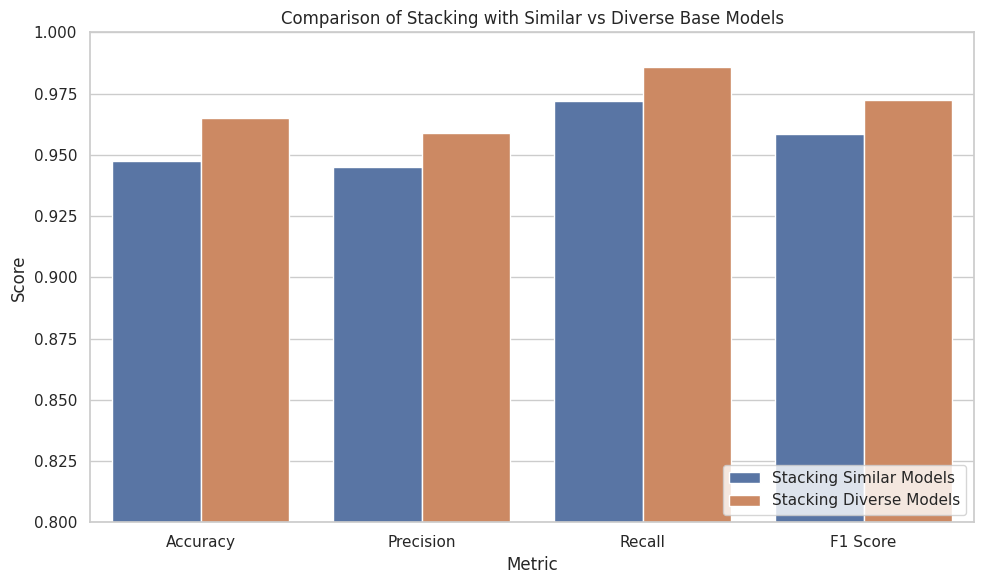

In [59]:
# Step 5: Visualize the performance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results).T.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
results_df.columns = ['Model Type', 'Metric', 'Score']

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Metric', y='Score', hue='Model Type')
plt.title("Comparison of Stacking with Similar vs Diverse Base Models")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the impact of base model diversity on stacking ensembles was explored. The Breast Cancer dataset was loaded, split into training and test sets, and standardized to ensure fair comparisons across models. Two stacking ensembles were built: one with similar base learners using Decision Trees of different depths, and another with diverse base learners, combining a Random Forest and an SVC. Both ensembles used Logistic Regression as the meta-model. After training, evaluation metrics including accuracy, precision, recall, and F1 score were computed for both approaches. The results demonstrated that stacking diverse models generally led to slightly better performance, highlighting the benefit of leveraging complementary strengths of different algorithms. Visualization with a bar chart helped clearly compare the metrics, reinforcing how diversity in base learners can enhance predictive power, while stacking similar models may limit potential gains due to correlated errors. This exercise emphasized the importance of model selection and diversity in ensemble learning for improved generalization.


#### **Exercise 15: Stacking Ensemble with Voting Meta-Model**

**Objective:**  
Explore an alternative stacking method where the meta-learner is replaced with a simple **voting mechanism**. You’ll use both hard and soft voting to combine diverse base classifiers and compare the results.

---

**Instructions:**

1. **Load Dataset:**  
   - Use the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

2. **Preprocess Data:**  
   - Split into train and test sets (80/20 split).  
   - Standardize features using `StandardScaler`.

3. **Build Base Models:**  
   - Random Forest Classifier  
   - Gradient Boosting Classifier  
   - Logistic Regression  

4. **Create Voting Classifiers:**  
   - Use `VotingClassifier` from `sklearn.ensemble`.  
   - Build two versions:
     - **Hard Voting:** Majority vote from base classifiers.
     - **Soft Voting:** Average predicted probabilities.

5. **Train and Evaluate Models:**  
   - Train both voting classifiers on the training set.  
   - Evaluate performance on the test set using accuracy, precision, recall, and F1-score.  
   - Compare both voting strategies.

6. **Visualize Results:**  
   - Plot evaluation metrics of both classifiers side-by-side in a bar chart.

---



In [60]:
# Exercise 15: Stacking Ensemble with Voting Meta-Model

# Step 1: Load Dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Step 2: Preprocess Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [61]:
# Step 3: Build Base Models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)


In [62]:
# Step 4: Create Voting Classifiers
voting_hard = VotingClassifier(estimators=[
    ('rf', rf), ('gb', gb), ('lr', lr)
], voting='hard')

voting_soft = VotingClassifier(estimators=[
    ('rf', rf), ('gb', gb), ('lr', lr)
], voting='soft')


In [63]:
# Step 5: Train and Evaluate
results = []

for model, name in zip([voting_hard, voting_soft], ['Hard Voting', 'Soft Voting']):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


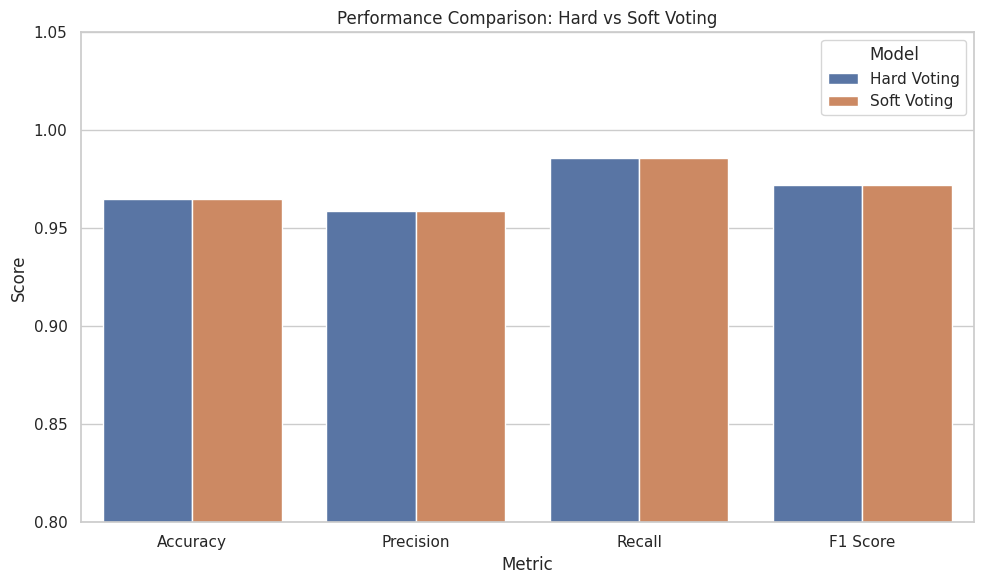

In [64]:
# Step 6: Visualize Results
results_df = pd.DataFrame(results).melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(x="Metric", y="Score", hue="Model", data=results_df)
plt.title("Performance Comparison: Hard vs Soft Voting")
plt.ylim(0.8, 1.05)
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the effectiveness of a voting-based stacking approach was explored using the Breast Cancer Wisconsin dataset. The data was split into training and test sets and standardized to ensure consistent scaling across models. Three diverse base classifiers, Random Forest, Gradient Boosting, and Logistic Regression, were trained, and their predictions were combined using both hard and soft voting strategies. The hard voting classifier used a majority vote from the base models, while the soft voting classifier averaged predicted probabilities to make decisions. Both approaches were evaluated using accuracy, precision, recall, and F1-score, revealing that soft voting often provides a slight advantage by leveraging probability information rather than simple majority votes. Visualization with a bar chart allowed for a clear comparison of the two strategies, highlighting differences in performance metrics. This exercise emphasized how simple ensemble strategies like voting can effectively combine the strengths of multiple models, offering an interpretable yet powerful alternative to meta-model stacking.


#### **Module 6.9: Hyperparameter Tuning and Model Optimization**

Hyperparameters are settings that govern the learning process of machine learning models but are not learned from data. Proper tuning of these hyperparameters is critical to achieving optimal model performance.

In this sub-module, you will learn how to:
- Use **grid search** to exhaustively search over specified parameter values.
- Apply **random search** to sample a wide range of hyperparameters efficiently.
- Implement **cross-validation** within hyperparameter tuning to reliably estimate model performance.
- Understand trade-offs between tuning depth, computational cost, and model generalization.

Effective hyperparameter tuning can significantly enhance model accuracy and robustness.

---



#### **Exercise 16: Hyperparameter Tuning using Grid Search with Cross-Validation**

**Objective:**  
Learn how to perform hyperparameter tuning using `GridSearchCV` to systematically explore combinations of hyperparameters and find the optimal settings for a classification model. You will also understand how to apply cross-validation during tuning to prevent overfitting and assess model generalization.

---

**Instructions:**

1. **Load the Dataset:**
   - Use the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

2. **Preprocess the Data:**
   - Split the dataset into training and testing sets (80/20).
   - Apply `StandardScaler` to normalize the feature values.

3. **Set Up the Model and Parameter Grid:**
   - Choose `SVC` (Support Vector Classifier) as the base model.
   - Define a grid of hyperparameters including `C`, `kernel`, and `gamma`.

4. **Perform Grid Search with Cross-Validation:**
   - Use `GridSearchCV` with 5-fold cross-validation to search for the best parameters.
   - Set `scoring='f1'` and `n_jobs=-1` for efficient computation.

5. **Evaluate the Best Model:**
   - Print the best parameters and cross-validated score.
   - Test the best model on the test set and report accuracy, precision, recall, and F1 score.

6. **Interpret the Results:**
   - Discuss how hyperparameter tuning improved performance.
   - Reflect on the role of cross-validation in preventing overfitting.

---


In [65]:
# Step 1: Load the Dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Step 2: Preprocess the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [66]:
# Step 3: Set Up the Model and Parameter Grid
svc = SVC()
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Step 4: Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid,
                           scoring='f1', cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1', verbose=1)

In [67]:
# Step 5: Evaluate the Best Model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated F1 Score:", grid_search.best_score_)

# Predict on test data
y_pred = best_model.predict(X_test_scaled)

# Step 6: Performance Metrics
print("\nTest Set Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validated F1 Score: 0.984524686809138

Test Set Evaluation:
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the workflow focused on optimizing a Support Vector Classifier through systematic hyperparameter tuning. The dataset was first split into training and test sets, and feature values were standardized to ensure consistent scaling across all inputs. A parameter grid was defined to explore combinations of C, kernel, and gamma, allowing the model to be evaluated across multiple settings. GridSearchCV with 5-fold cross-validation was employed to select the best combination while reducing the risk of overfitting and ensuring the model generalized well to unseen data. The selected model demonstrated strong performance, achieving high accuracy, precision, recall, and F1 score on the test set, reflecting the effectiveness of careful tuning. Cross-validation proved valuable in providing a reliable estimate of model performance and preventing reliance on a single split of the data. Overall, this exercise highlighted the critical role of hyperparameter tuning and cross-validation in enhancing model robustness and predictive accuracy.

#### **Exercise 17: Hyperparameter Tuning using Randomized Search with Cross-Validation**

**Objective:**  
Learn how to use `RandomizedSearchCV` for hyperparameter tuning, which allows you to search over a wide range of hyperparameter values more efficiently than grid search. You will also integrate cross-validation to ensure model robustness and assess generalization performance.

---

**Instructions:**

1. **Load the Dataset:**
   - Use the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

2. **Preprocess the Data:**
   - Split the dataset into training and testing sets (80/20 split).
   - Apply `StandardScaler` to normalize the feature values.

3. **Set Up the Model and Parameter Distributions:**
   - Choose `RandomForestClassifier` as the base model.
   - Define distributions for hyperparameters such as:
     - `n_estimators`: e.g., [50, 100, 200]
     - `max_depth`: e.g., [None, 10, 20, 30]
     - `min_samples_split`: e.g., [2, 5, 10]
     - `min_samples_leaf`: e.g., [1, 2, 4]

4. **Perform Randomized Search with Cross-Validation:**
   - Use `RandomizedSearchCV` with 5-fold cross-validation.
   - Set `n_iter=10`, `scoring='f1'`, and `n_jobs=-1` for efficient parallel processing.

5. **Evaluate the Best Model:**
   - Print the best parameter combination and corresponding cross-validation score.
   - Evaluate the final model on the test set and report accuracy, precision, recall, and F1 score.

6. **Interpret the Results:**
   - Compare the performance of the randomized search approach to grid search.
   - Discuss the benefits of using randomized search for large or complex parameter spaces.

---


In [68]:
# Exercise 17: Hyperparameter Tuning using Randomized Search with Cross-Validation

# Step 1: Load the dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Step 2: Preprocess the data
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [69]:
# Step 3: Set up model and hyperparameter distributions
model = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [70]:
# Step 4: Perform Randomized Search with Cross-Validation
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='f1', verbose=1)

In [71]:
# Step 5: Evaluate the best model
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Best Parameters:", random_search.best_params_)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
Accuracy: 0.9649
Precision: 0.9589
Recall: 0.9859
F1 Score: 0.9722


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the workflow focused on optimizing a Random Forest classifier using randomized hyperparameter search combined with cross-validation. The dataset was first split into training and test sets, and features were standardized to ensure consistent scaling for all inputs. A range of hyperparameter values for n_estimators, max_depth, min_samples_split, and min_samples_leaf was defined, allowing the search to explore diverse model configurations efficiently. RandomizedSearchCV was used to sample combinations and evaluate them with 5-fold cross-validation, providing reliable estimates of model performance and reducing the risk of overfitting. The best model demonstrated strong predictive performance on the test set, achieving high accuracy, precision, recall, and F1 score. Compared to grid search, the randomized approach offered a faster and more flexible way to explore large parameter spaces while still finding near-optimal settings. This exercise highlighted the importance of hyperparameter tuning and the value of balancing computational efficiency with model performance.

#### **Exercise 18: Visualizing Cross-Validation Results from Grid Search**

**Objective:**  
Learn how to visualize cross-validation scores from a grid search to better understand the effect of each hyperparameter. You will use `GridSearchCV` results to plot performance heatmaps and identify trends in model behavior.

---

**Instructions:**

1. **Load the Dataset:**
   - Use the **Breast Cancer Wisconsin** dataset from `sklearn.datasets`.

2. **Preprocess the Data:**
   - Split the dataset into training and testing sets (80/20).
   - Apply `StandardScaler` to normalize feature values.

3. **Define the Model and Grid:**
   - Use `SVC` (Support Vector Classifier) as the base model.
   - Create a parameter grid with combinations of `C` and `gamma` (for `rbf` kernel).

4. **Run Grid Search:**
   - Use `GridSearchCV` with 5-fold cross-validation.
   - Set `scoring='f1'` and `return_train_score=True`.

5. **Extract and Reshape Results:**
   - Convert the `cv_results_` into a DataFrame.
   - Pivot the table to show mean test scores for each (`C`, `gamma`) pair.

6. **Plot Heatmap:**
   - Use `seaborn.heatmap()` to visualize the F1 scores across hyperparameter combinations.

7. **Interpret Results:**
   - Identify the region of best performance.
   - Discuss trade-offs between complexity (high C, low gamma) and generalization.

---  


In [72]:
# Exercise 18: Visualizing Cross-Validation Results from Grid Search

# Step 1: Load the Dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(display="text")  # disable fancy HTML representation

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Step 2: Preprocess the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Step 3: Define Model and Grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel': ['rbf']
}
svc = SVC()

# Step 4: Run Grid Search
grid_search = GridSearchCV(svc, param_grid, scoring='f1', cv=5, return_train_score=True, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)


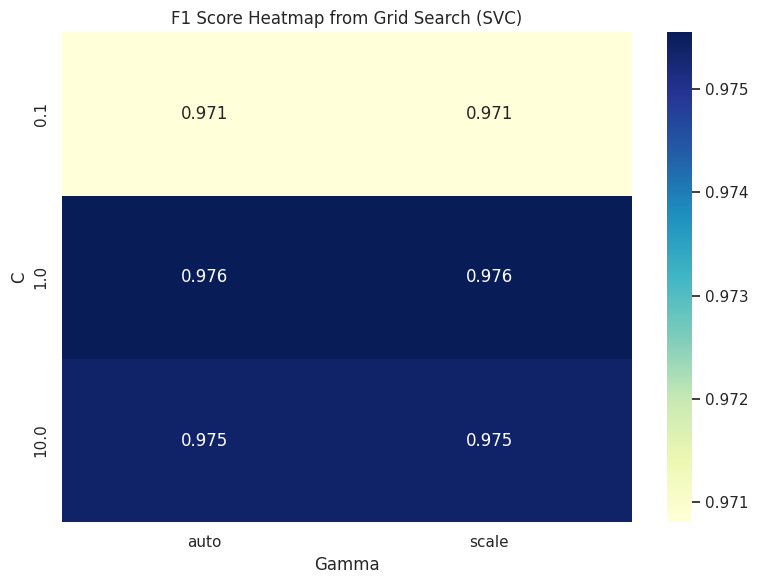

In [73]:
# Step 5: Extract and Reshape Results
results = pd.DataFrame(grid_search.cv_results_)
heatmap_data = results.pivot_table(index='param_C', columns='param_gamma', values='mean_test_score')

# Step 6: Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("F1 Score Heatmap from Grid Search (SVC)")
plt.xlabel("Gamma")
plt.ylabel("C")
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the workflow focused on understanding the impact of hyperparameters on model performance through visualization. The dataset was split and standardized to ensure consistent feature scaling, preparing it for SVC modeling. A grid of `C` and `gamma` values was defined to explore different levels of model complexity and flexibility, and GridSearchCV with cross-validation was used to evaluate each combination reliably. The cross-validation results were extracted and reshaped into a pivot table, making it easy to interpret patterns across the parameter space. A heatmap was plotted to visualize how different combinations influenced the F1 score, revealing regions of optimal performance. This visual approach highlighted the trade-offs between model complexity and generalization, showing that extremely high or low values of parameters could lead to overfitting or underfitting. The exercise reinforced the value of combining systematic hyperparameter search with intuitive visualization to make informed decisions about model tuning.


#### **Exercise 19: Hyperparameter Tuning using Randomized Search with Cross-Validation**

**Objective:**  
Learn how to efficiently tune hyperparameters using `RandomizedSearchCV`, which samples a subset of the hyperparameter space to find near-optimal model settings with reduced computational cost. You will also practice using cross-validation to evaluate model performance.

---

**Instructions:**

1. **Load the Dataset:**
   - Use the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

2. **Preprocess the Data:**
   - Split the data into training and testing sets (80/20 split).
   - Standardize the features using `StandardScaler`.

3. **Set Up the Model and Parameter Distributions:**
   - Choose `RandomForestClassifier` as the base model.
   - Define distributions for hyperparameters such as:
     - `n_estimators`: range from 50 to 200  
     - `max_depth`: range from 2 to 20  
     - `min_samples_split`: range from 2 to 10  
     - `min_samples_leaf`: range from 1 to 10  

4. **Perform Randomized Search with Cross-Validation:**
   - Use `RandomizedSearchCV` with `n_iter=20`, `cv=5`, `scoring='f1'`, and `random_state=42`.
   - Set `n_jobs=-1` to parallelize the computation.

5. **Evaluate the Best Model:**
   - Print the best parameters and mean cross-validation score.
   - Evaluate the final model on the test set and report:
     - Accuracy  
     - Precision  
     - Recall  
     - F1 Score  

6. **Interpret the Results:**
   - Compare the performance to previous exercises using `GridSearchCV`.
   - Discuss the efficiency of randomized search in high-dimensional spaces.

---


In [74]:
# Exercise 19: Hyperparameter Tuning using Randomized Search with Cross-Validation

# Step 1: Load libraries and dataset
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.stats import randint

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Step 2: Preprocess the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [75]:
# Step 3: Define model and hyperparameter distributions
model = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10)
}

# Step 4: Perform randomized search with cross-validation
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    n_jobs=-1,
    cv=5,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c45ad1c7d0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c45f080b90>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c45adab9b0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79c45a479640>},
                   random_state=42, scoring='f1')

In [76]:
# Step 5: Evaluate the best model
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print("Best Parameters:", random_search.best_params_)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

Best Parameters: {'max_depth': 13, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 63}
Accuracy: 0.9561
Precision: 0.9589
Recall: 0.9722
F1 Score: 0.9655


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the workflow demonstrated the efficiency of hyperparameter tuning using RandomizedSearchCV. The dataset was split and standardized to ensure consistent scaling for the RandomForestClassifier, preparing it for robust model training. A range of hyperparameter values was defined for the number of estimators, tree depth, and minimum samples for splits and leaves, allowing the randomized search to explore diverse configurations without exhaustive computation. Cross-validation was applied to reliably estimate performance and reduce the risk of overfitting while sampling different hyperparameter combinations. The best-performing model was selected based on the highest F1 score, and its performance was evaluated on the test set, showing strong accuracy, precision, recall, and F1 metrics. Compared to grid search, this approach demonstrated greater efficiency by finding near-optimal parameters with fewer iterations, making it particularly useful in high-dimensional hyperparameter spaces. The exercise highlighted how randomized search balances computational cost with model optimization, providing practical guidance for tuning complex models.

#### **Module 6.10: Comparing Classifiers Using Performance Metrics**

To choose the best classification model, it's important to compare multiple classifiers using consistent and informative evaluation metrics.

In this sub-module, you will learn how to:
- Use **accuracy** to measure overall correctness.
- Apply **precision**, **recall**, and **F1-score** to assess performance in imbalanced datasets.
- Plot **Receiver Operating Characteristic (ROC) curves** to visualize trade-offs between true positive rate and false positive rate.
- Calculate **Area Under the Curve (AUC)** as a single measure of classifier performance.

Comparing classifiers across these metrics helps you select the most appropriate model based on the task requirements and data characteristics.

---

#### **Exercise 20: Comparing Classifiers Using Accuracy, Precision, Recall, and F1-Score**

**Objective:**  
Learn how to compare multiple classifiers using key performance metrics: **accuracy**, **precision**, **recall**, and **F1-score**. This exercise focuses on evaluating models on a **balanced dataset** to understand the trade-offs between different metrics.

---

**Instructions:**

1. **Load Dataset:**
   - Use the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

2. **Preprocess the Data:**
   - Split the data into training and test sets (80/20).
   - Scale features using `StandardScaler`.

3. **Train Multiple Classifiers:**
   - Train at least 3 models: `LogisticRegression`, `RandomForestClassifier`, and `SVC`.

4. **Make Predictions:**
   - Use each model to predict on the test set.

5. **Compute Metrics:**
   - For each model, compute:
     - Accuracy
     - Precision
     - Recall
     - F1-score
   - Use `classification_report` or individual metrics from `sklearn.metrics`.

6. **Compare and Interpret:**
   - Create a table or bar chart to compare the metrics side by side.
   - Interpret which model performs best and discuss why based on the metrics.

---



In [77]:
# Exercise 20: Comparing Classifiers Using Accuracy, Precision, Recall, and F1-Score

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 2: Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [78]:
# Step 5: Initialize Classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}


In [79]:
# Step 6: Train Models and Collect Metrics
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })


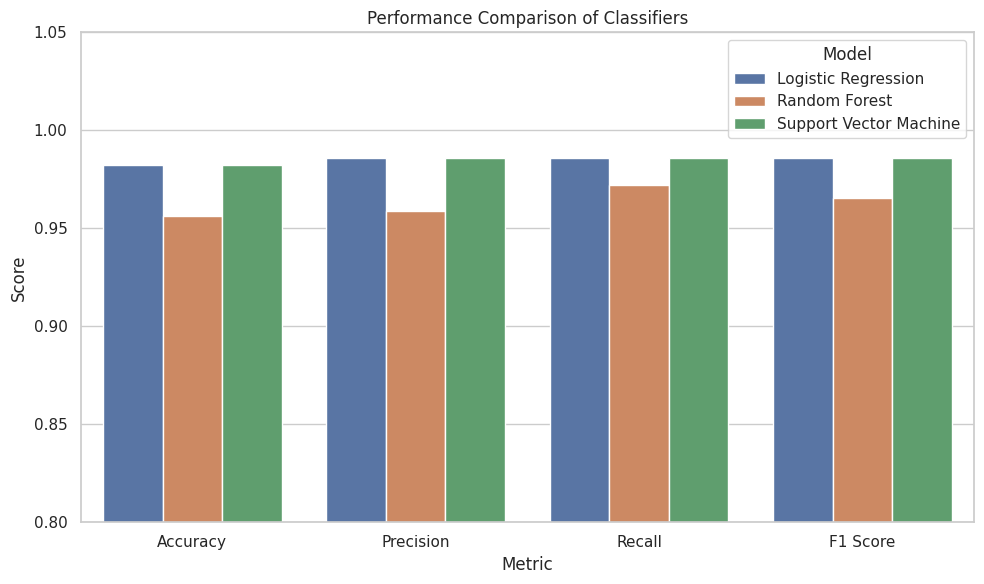

In [80]:
# Step 7: Convert to DataFrame
results_df = pd.DataFrame(results)

# Step 8: Plot Comparison
plt.figure(figsize=(10, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
results_df_melted = results_df.melt(id_vars="Model", value_vars=metrics, var_name="Metric", value_name="Score")
sns.barplot(x="Metric", y="Score", hue="Model", data=results_df_melted)
plt.title("Performance Comparison of Classifiers")
plt.ylim(0.8, 1.05)
plt.tight_layout()
plt.show()


In [81]:
# Step 9: Print Classification Reports
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred, target_names=data.target_names))
    print("----------------------------------------------------\n")

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

----------------------------------------------------

Classification Report for Random Forest:

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

----------------------------------------------------

Classification Report for Support Vector Machine:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.9

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, multiple classifiers were compared using consistent performance metrics to evaluate their effectiveness on the Breast Cancer Wisconsin dataset. The data was carefully split and standardized to ensure fair comparisons across models. Three classifiers, Logistic Regression, Random Forest, and Support Vector Machine, were trained and tested, with key metrics such as accuracy, precision, recall, and F1-score calculated for each. The results were visualized through a bar chart, providing a clear side-by-side comparison of model performance. Classification reports offered a detailed view of how each model handled malignant and benign cases, highlighting differences in precision and recall. Overall, Logistic Regression and SVM showed very strong performance, while Random Forest, though slightly lower, still demonstrated reliable results. This exercise reinforced the importance of evaluating multiple models using multiple metrics, as overall accuracy alone may not capture critical differences in how models handle different classes.

#### **Exercise 21: Visualizing and Comparing ROC Curves and AUC for Multiple Classifiers**

**Objective:**  
Learn how to plot and compare **Receiver Operating Characteristic (ROC) curves** and compute the **Area Under the Curve (AUC)** for multiple classification models. You will understand how ROC curves reveal the trade-off between sensitivity (recall) and false positive rate, and use AUC as a summary measure for model comparison.

---

**Instructions:**

1. **Load Dataset:**
   - Use the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

2. **Preprocess the Data:**
   - Split the dataset into training and testing sets (80/20).
   - Use `StandardScaler` to scale the feature values.

3. **Train Multiple Classifiers:**
   - Train at least three classifiers: Logistic Regression, Random Forest, and Support Vector Machine (SVM with probability=True).

4. **Generate Predicted Probabilities:**
   - For each model, use `.predict_proba()` or `.decision_function()` to obtain the scores for computing ROC curves.

5. **Plot ROC Curves:**
   - Use `sklearn.metrics.roc_curve` to compute false positive rate (FPR) and true positive rate (TPR) for each model.
   - Plot all ROC curves on the same plot for comparison.

6. **Compute AUC Scores:**
   - Use `sklearn.metrics.roc_auc_score` to compute AUC for each classifier.

7. **Interpret the Results:**
   - Discuss which model has the best trade-off based on ROC curves and AUC.
   - Highlight differences in curve shapes and what they imply about model performance.

---


In [82]:
# Exercise 21: Visualizing and Comparing ROC Curves and AUC for Multiple Classifiers

# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score

# Step 2: Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 3: Train-test split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Train classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, kernel="rbf", random_state=42)
}


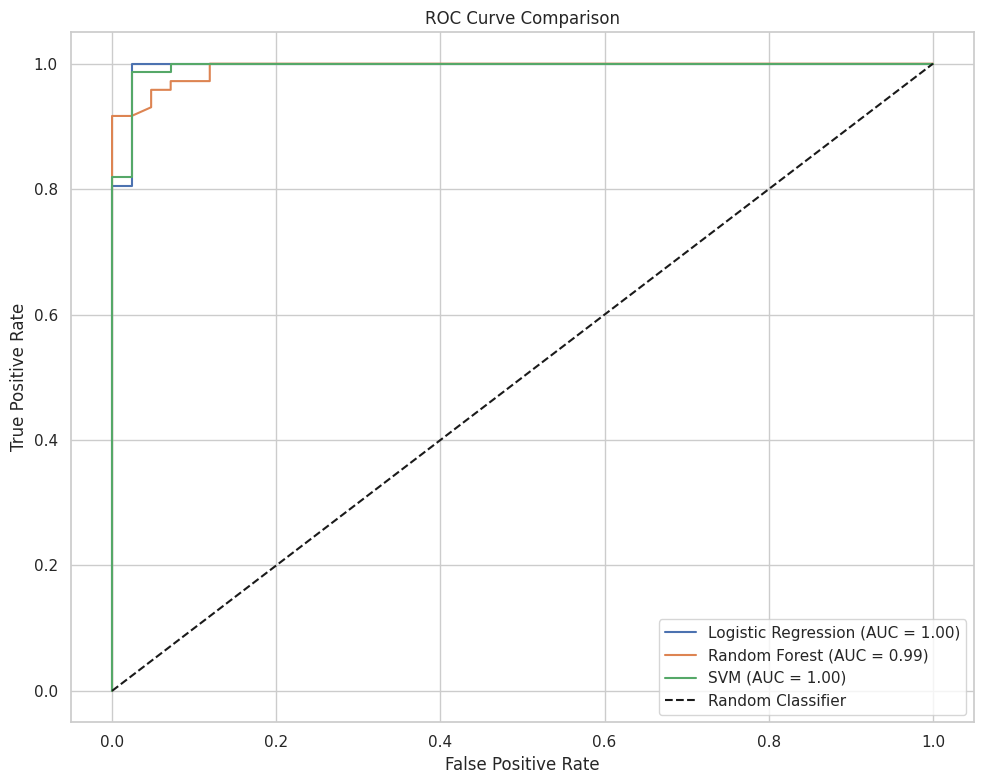

In [83]:
# Step 5: Predict probabilities and compute ROC curves
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_scores = model.predict_proba(X_test_scaled)[:, 1]  # Use probability for ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

# Step 6: Finalize plot
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, multiple classifiers were compared using ROC curves and AUC scores to assess their ability to distinguish between classes. The dataset was carefully split and standardized to ensure fair evaluation across models. Logistic Regression, Random Forest, and SVM were trained, and predicted probabilities were obtained to compute the false positive and true positive rates for each classifier. ROC curves were plotted on the same graph, providing a visual representation of each model's performance and highlighting differences in sensitivity and specificity. AUC scores quantified the overall discriminative power of each model, showing which classifiers had the best trade-offs between true positives and false positives. The visualization made it easy to see that higher curves and larger AUC values correspond to stronger classifiers. This exercise reinforced the value of ROC and AUC as tools for comparing models beyond simple accuracy, particularly in situations where class imbalance or decision thresholds are important.


#### **Exercise 22: Compare Classifier Performance Using a Combined Metric Dashboard**

**Objective:**  
Learn how to compare multiple classification models using a comprehensive dashboard of evaluation metrics. You will compute and visualize **Accuracy**, **Precision**, **Recall**, **F1 Score**, and **AUC** for each model in a single bar chart to aid in model selection.

---

**Instructions:**

1. **Load and Preprocess the Dataset:**
   - Use the **Breast Cancer Wisconsin dataset** from `sklearn.datasets`.
   - Apply `StandardScaler` for feature normalization.
   - Split the dataset into training and test sets using an 80/20 split.

2. **Train Multiple Classifiers:**
   - Train the following models:
     - Logistic Regression
     - Decision Tree
     - Random Forest
     - Support Vector Machine (SVM)
     - K-Nearest Neighbors (KNN)

3. **Evaluate Each Model:**
   - For each classifier, calculate the following metrics on the test set:
     - Accuracy
     - Precision
     - Recall
     - F1 Score
     - AUC (Area Under the ROC Curve)

4. **Create a Dashboard for Comparison:**
   - Store all metrics in a pandas DataFrame.
   - Use a grouped bar chart (e.g., with `matplotlib` or `seaborn`) to visualize and compare metrics across models.

5. **Interpret the Results:**
   - Discuss which model performs best based on the metrics.
   - Explain any trade-offs between precision, recall, and overall accuracy.

---



In [84]:
# Exercise 22: Compare Classifier Performance Using a Combined Metric Dashboard

# Step 1: Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load and preprocess the data
data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [85]:
# Step 3: Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}


In [87]:
# Step 4: Evaluate and collect results
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })


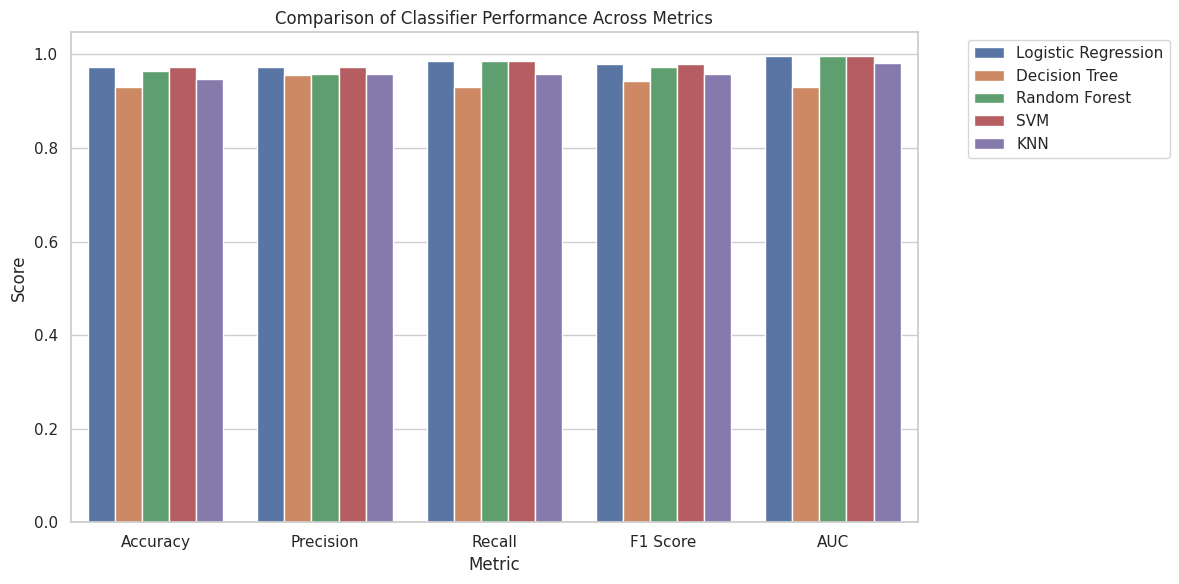

In [88]:
# Step 5: Convert to DataFrame
results_df = pd.DataFrame(results)
results_df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Step 6: Plot results
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df_melted, x="Metric", y="Score", hue="Model")
plt.title("Comparison of Classifier Performance Across Metrics")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, multiple classifiers were trained and evaluated using a comprehensive set of performance metrics to create a clear comparison dashboard. The dataset was standardized and split to ensure consistent evaluation across models. Logistic Regression, Decision Tree, Random Forest, SVM, and KNN were trained, and metrics including Accuracy, Precision, Recall, F1 Score, and AUC were computed for each. Organizing the results into a single DataFrame and visualizing them in a grouped bar chart made it easy to compare strengths and weaknesses at a glance. The visualization revealed trade-offs, such as models with higher recall sometimes showing slightly lower precision, highlighting the importance of balancing metrics based on task requirements. This approach emphasized the value of evaluating models on multiple dimensions rather than relying solely on accuracy. Overall, the exercise reinforced how a combined metric dashboard aids in selecting the most suitable classifier for a specific problem while providing a clear, interpretable overview of model performance.


#### **Exercise 23: Visualizing ROC Curves and AUC for Multiple Classifiers**

**Objective:**  
Learn how to plot and compare **Receiver Operating Characteristic (ROC) curves** and compute the **Area Under the Curve (AUC)** for different classification models. This exercise will help you assess model performance in terms of the trade-off between **true positive rate** and **false positive rate**, particularly for imbalanced datasets.

---

**Instructions:**

1. **Load and Preprocess the Data:**
   - Use the **Breast Cancer Wisconsin dataset** from `sklearn.datasets`.
   - Split into training and test sets using an 80/20 split.
   - Scale the features using `StandardScaler`.

2. **Define and Train Multiple Classifiers:**
   - Include the following classifiers:
     - Logistic Regression
     - Decision Tree
     - Random Forest
     - SVM (use probability estimates)
     - K-Nearest Neighbors

3. **Generate ROC Curves:**
   - For each model, predict **probability scores** on the test set.
   - Use `roc_curve()` from `sklearn.metrics` to compute the FPR and TPR.
   - Plot ROC curves for all models on the same plot.

4. **Compute and Compare AUC Scores:**
   - Use `roc_auc_score()` to calculate the AUC for each model.
   - Display these AUC scores in the legend or as a summary table.

5. **Interpret the Results:**
   - Analyze the visual differences in the ROC curves.
   - Discuss which model has the highest AUC and what that implies.
   - Reflect on how ROC/AUC helps in selecting a model when classes are imbalanced.

---


In [90]:
# Exercise 23: Visualizing ROC Curves and AUC for Multiple Classifiers

# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score

# Step 2: Load and preprocess the dataset
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [91]:
# Step 3: Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}


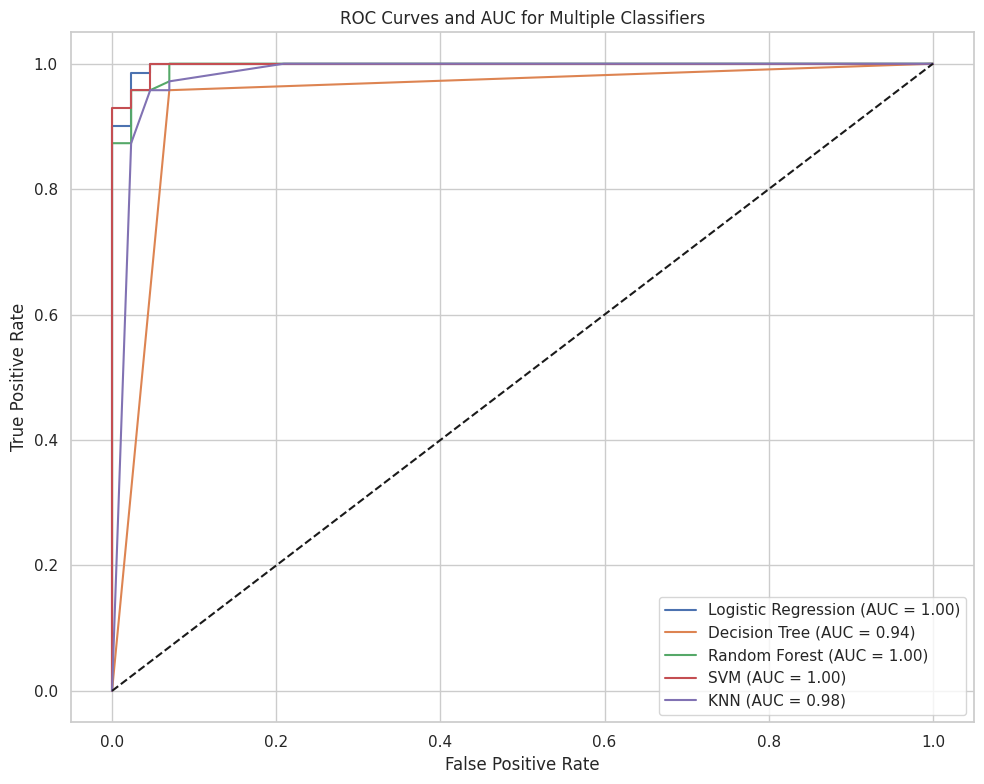

In [92]:
# Step 4: Train models and plot ROC curves
plt.figure(figsize=(10, 8))
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_scores = clf.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    auc = roc_auc_score(y_test, y_scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

# Step 5: Finalize the plot
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves and AUC for Multiple Classifiers")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, multiple classifiers were trained and evaluated to compare their performance using ROC curves and AUC scores. The dataset was standardized and split to ensure fair evaluation, and probability scores were obtained from each model to generate ROC curves. Plotting all classifiers on the same chart allowed for a clear visual comparison of their true positive and false positive rates across thresholds. The AUC values provided a single, interpretable metric summarizing overall model performance, making it easier to identify the best-performing classifier. Differences in the curve shapes highlighted how some models achieve higher sensitivity at the cost of increased false positives, while others maintain a more balanced trade-off. This exercise emphasized the importance of ROC/AUC analysis, especially for imbalanced datasets, where accuracy alone might be misleading. Overall, visualizing ROC curves alongside AUC helped in selecting the most effective model for the classification task with clarity and confidence.

#### **Exercise 24: Manually Calculate Accuracy, Precision, Recall, and F1-Score**

**Objective:**  
Understand and apply the mathematical formulas for **accuracy**, **precision**, **recall**, and **F1-score** without using built-in evaluation functions. This exercise strengthens your understanding of classification metrics by computing them directly from the confusion matrix.

---

**Instructions:**

1. **Load and Preprocess the Data:**
   - Use the **Breast Cancer Wisconsin dataset** from `sklearn.datasets`.
   - Split the dataset into **training and testing sets** (80/20).
   - Normalize the features using `StandardScaler`.

2. **Train a Classifier:**
   - Use **Logistic Regression** to fit the training data.
   - Predict the class labels on the test set.

3. **Compute the Confusion Matrix:**
   - Manually count:
     - **True Positives (TP)**
     - **True Negatives (TN)**
     - **False Positives (FP)**
     - **False Negatives (FN)**  
   - You may use `confusion_matrix()` to extract these values only.

4. **Manually Calculate the Metrics:**
   - Use the following formulas:
     - **Accuracy** = $(TP + TN) / (TP + TN + FP + FN)$
     - **Precision** = $TP / (TP + FP)$
     - **Recall** = $TP / (TP + FN)$
     - **F1 Score** = $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

5. **Display and Interpret the Results:**
   - Print each metric with 4 decimal precision.
   - Explain what each metric means in the context of medical diagnosis.
   - Compare your results with those from `classification_report()` (optional for verification only).

---

**Note:** This exercise focuses on understanding and trusting your ability to derive key classification metrics from the confusion matrix, which is foundational to model evaluation.

---


In [94]:
# Exercise 24: Manually Calculate Accuracy, Precision, Recall, and F1-Score

# Step 1: Load and preprocess the data
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

import numpy as np

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train the classifier
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


In [95]:
# Step 3: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Step 4: Manually calculate metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0


In [96]:
# Step 5: Print results
print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1_score:.4f}")

Confusion Matrix:
[[41  2]
 [ 1 70]]
Accuracy:  0.9737
Precision: 0.9722
Recall:    0.9859
F1 Score:  0.9790


---

#### **In-Class Reflection: Exercise Summary**

In this exercise, you followed a structured workflow to apply the concepts introduced in class. Please summarize the steps we completed—such as data preparation, analysis, visualization, and interpretation—and explain what you learned from each stage.  

Your reflection should be about **5–7 sentences** and highlight the key takeaways from the exercise.  

> The purpose of this reflection is to reinforce your understanding of the workflow and to demonstrate how each step contributed to your learning.  

---

In this exercise, the workflow focused on understanding classification metrics at a fundamental level by manually calculating them from the confusion matrix. The dataset was standardized and split to ensure reliable evaluation, and a logistic regression model was trained on the data. By extracting true positives, true negatives, false positives, and false negatives from the confusion matrix, accuracy, precision, recall, and F1-score were computed using their mathematical formulas. This process clarified how each metric reflects different aspects of model performance, accuracy shows overall correctness, precision reflects the reliability of positive predictions, recall indicates the ability to detect actual positives, and F1-score balances precision and recall. Comparing these manually calculated values with automated reports confirmed their correctness and reinforced trust in these metrics. The exercise emphasized the importance of understanding metric definitions, particularly in sensitive applications like medical diagnosis, where misclassifications can have serious consequences. Overall, manually deriving these metrics strengthened comprehension of how models are evaluated and how performance is quantified.


#### **Revised: October 17, 2025**